# **Clasificar a los Pacientes en Grupos Normal y Anormal según los Criterios de la OMS para Comparar sus Parámetros Seminales**

## **Librerías Importadas**

In [2]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.stats import shapiro, levene, f_oneway, kruskal, ks_2samp, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display


In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## **Lectura de Datos**

In [4]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [5]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Funciones**

### **Análisis Descriptivo y Visual de la Distribución Temporal de Variables Numéricas**

Para caracterizar el comportamiento de las variables numéricas del espermograma a lo largo del tiempo, se genera un análisis descriptivo que incluye estadísticos por año (recuento, media, desviación estándar, percentiles, asimetría y curtosis), así como indicadores de dispersión como el rango intercuartílico y el coeficiente de variación. Complementariamente, se elabora una representación gráfica mediante violinplots con boxplots superpuestos, que permite visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos para cada año. Esta combinación de análisis estadístico y visual facilita la identificación de tendencias temporales, cambios en la variabilidad y posibles anomalías en la distribución de las variables a lo largo del período estudiado.

In [6]:
colors = [
    "#4E79A7",  # Azul
    "#F28E2B",  # Naranja
    "#59A14F",  # Verde
    "#E15759",  # Rojo
    "#B07AA1",  # Morado
    "#76B7B2",  # Turquesa
    "#EDC948",  # Mostaza
    "#9C755F",  # Marrón
    "#BAB0AC",  # Gris
    "#7F7F7F",  # Gris oscuro
    "#2F4B7C"   # Azul marino
]

def graficas_numericas(df, var, nombre_parametro=None, color=None):

    """Genera un violinplot con boxplot superpuesto y muestra la tabla descriptiva."""

    label_param = nombre_parametro if nombre_parametro else var

    tabla = df.groupby("año")[var].agg(
        Count="count",
        Mean="mean",
        Std="std",
        Min="min",
        Q1=lambda x: x.quantile(0.25),
        Q2="median",
        Q3=lambda x: x.quantile(0.75),
        Max="max",
        Skew="skew",
        Kurtosis="kurt",
    )

    tabla["IQR"] = tabla["Q3"] - tabla["Q1"]
    tabla["CV"] = np.where(
        tabla["Mean"] != 0, (tabla["Std"] / tabla["Mean"]) * 100, np.nan
    )

    columnas_orden = [
        "Count",
        "Mean",
        "Std",
        "Min",
        "Q1",
        "Q2",
        "Q3",
        "Max",
        "IQR",
        "CV",
        "Skew",
        "Kurtosis",
    ]
    tabla = tabla[columnas_orden]

    print(f"Estadísticos de {label_param} según Año de Estudio")
    display(tabla)

    datos_violin = df[["año", var]].dropna()
    años_unicos = sorted(datos_violin["año"].unique())
    datos_por_año = [
        datos_violin[datos_violin["año"] == año][var].values
        for año in años_unicos
    ]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    partes_violin = ax.violinplot(
        datos_por_año,
        positions=años_unicos,
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for patch in partes_violin["bodies"]:
        patch.set_facecolor(
            color
        )
        patch.set_alpha(0.5)
        patch.set_edgecolor("white")
        patch.set_linewidth(0.5)

    boxprops = {
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.5,
        "alpha": 0.8,
    }
    whiskerprops = {"color": "black", "linewidth": 1.5, "linestyle": "-"}
    capprops = {"color": "black", "linewidth": 1.5}
    medianprops = {"color": "black", "linewidth": 2, "linestyle": "-"}
    flierprops = {
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5,
        "alpha": 0.6,
    }

    ax.boxplot(
        datos_por_año,
        positions=años_unicos,
        widths=0.25,
        patch_artist=True,
        showmeans=False,
        showfliers=True,
        flierprops=flierprops,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
        manage_ticks=False,
    )

    ax.set_xlabel("Año", fontsize=12, fontweight="bold")
    ax.set_ylabel(label_param, fontsize=12, fontweight="bold")
    ax.set_title(
        f"Distribución Temporal de {label_param}",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    ax.set_xticks(años_unicos)
    ax.set_xticklabels(años_unicos, fontsize=10)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(False)

    y_min, y_max = datos_violin[var].min(), datos_violin[var].max()
    rango = y_max - y_min if y_max != y_min else 1.0
    ax.set_ylim(y_min - 0.05 * rango, y_max + 0.05 * rango)

    plt.tight_layout()
    plt.show()
    print("")

### **Análisis Estadístico Comparativo de Variables entre Dos Conjuntos de Datos**

La función `funcion_numericas_dos_datasets` implementa un sistema completo de análisis estadístico para comparar el comportamiento de una variable numérica a lo largo del tiempo entre dos conjuntos de datos diferentes. El análisis se estructura en tres etapas: primero, se realiza un análisis individual de cada dataset mediante la función auxiliar `_analizar_dataset`, que incluye pruebas de normalidad de Shapiro-Wilk aplicadas tanto al conjunto completo (cuando el tamaño muestral está entre 3 y 5000) como a cada año de forma independiente, donde los años con menos de 3 observaciones se consideran automáticamente no normales. Posteriormente, se evalúa la homogeneidad de varianzas mediante la prueba de Levene, considerando únicamente los años con al menos 2 observaciones. Con base en el cumplimiento de los supuestos de normalidad (global y por años) y homogeneidad de varianzas, el sistema selecciona automáticamente entre ANOVA paramétrico con post-hoc Tukey HSD o Kruskal-Wallis no paramétrico con post-hoc Dunn, aplicando las pruebas post-hoc solo cuando se detectan diferencias significativas.

En la segunda etapa, la función `_comparar_datasets_por_año` realiza el análisis inter-datasets, comenzando con la identificación de años comunes entre ambos conjuntos de datos. Para cada año común donde ambos datasets cuentan con al menos 3 observaciones, se aplica la prueba de Mann-Whitney para comparar las distribuciones entre datasets, reportando el estadístico U y el valor p asociado. Adicionalmente, se realiza la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales de ambos datasets, siempre que ambos cuenten con al menos 3 observaciones. Finalmente, el sistema genera un resumen que indica si se encontraron diferencias significativas entre los datasets en al menos un año, proporcionando así una evaluación robusta y completa de las diferencias estadísticamente significativas entre ambos conjuntos de datos a lo largo del periodo de estudio.

In [7]:
def funcion_numericas_dos_datasets(
    dataset1,
    dataset2,
    variable_name,
    dataset1_nombre="Dataset 1",
    dataset2_nombre="Dataset 2",
):
    
    """Analiza dos datasets de forma individual y luego los compara."""

    print(f"\n=== Análisis Individual: {dataset1_nombre} ===")

    _analizar_dataset(dataset1, variable_name, dataset1_nombre)

    print(f"\n\n=== Análisis Individual: {dataset2_nombre} ===")

    _analizar_dataset(dataset2, variable_name, dataset2_nombre)

 
    print(f"\n\n=== Comparación entre Datasets por Año ===")

    _comparar_datasets_por_año(
        dataset1,
        dataset2,
        variable_name,
        nombre1=dataset1_nombre,
        nombre2=dataset2_nombre,
    )


def _analizar_dataset(df, variable_name, dataset_nombre):
    """Análisis completo individual de un dataset."""
    datos_limpios = df[[variable_name, "año"]].dropna()
    años = sorted(datos_limpios["año"].unique())

    print(f"\nPrueba de Normalidad Global ({dataset_nombre})")
    datos_completos = datos_limpios[variable_name]
    n_total = len(datos_completos)

    if 3 <= n_total <= 5000:
        stat_global, p_global = shapiro(datos_completos)
        normal_global = p_global > 0.05
        estado_global = "Normal" if normal_global else "No Normal"
        p_text = "<1e-10" if p_global < 1e-10 else f"{p_global:.2e}"
        print(f"- n = {n_total}, p-value = {p_text} → {estado_global}")
    else:
        print(f"- n = {n_total} (Shapiro válido solo para 3 ≤ n ≤ 5000)")
        normal_global = False

    print(f"\nPruebas de Normalidad por Año")
    supuesto_normalidad = True

    for año in años:
        datos_año = datos_limpios[datos_limpios["año"] == año][variable_name]
        n = len(datos_año)

        if 3 <= n <= 5000:
            _, shapiro_p = shapiro(datos_año)
            normal = shapiro_p > 0.05
            estado = "Normal" if normal else "No Normal"
            shapiro_text = (
                "<1e-10" if shapiro_p < 1e-10 else f"{shapiro_p:.2e}"
            )
            print(f"- Año {int(año)}: n = {n}, p-value = {shapiro_text} → {estado}")

            if not normal:
                supuesto_normalidad = False
        elif n > 5000:
            print(f"- Año {int(año)}: n = {n} → Shapiro no aplicable (n > 5000)")
            supuesto_normalidad = False
        else:
            print(f"- Año {int(año)}: n = {n} → Muestra insuficiente (n < 3)")
            supuesto_normalidad = False

    grupos = []
    años_filtrados = []

    for año in años:
        datos_año = datos_limpios[datos_limpios["año"] == año][variable_name].values
        if len(datos_año) >= 2:
            grupos.append(datos_año)
            años_filtrados.append(int(año))

    if len(grupos) < 2:
        print(
            "\nNo hay suficientes grupos con n >= 2 para realizar ANOVA/Kruskal."
        )
        return

    print(f"\nGrupos incluidos en el análisis: {años_filtrados}")

    print(f"\nPrueba de Homogeneidad de Varianzas")
    levene_stat, levene_p = levene(*grupos)
    homogeneo = levene_p > 0.05
    levene_text = "<1e-10" if levene_p < 1e-10 else f"{levene_p:.2e}"
    print(f"- Levene: estadístico = {levene_stat:.2f}, p-value = {levene_text}")

    print(f"\nAnálisis Principal")
    usar_parametrico = supuesto_normalidad and homogeneo

    if usar_parametrico:
        print("- Método: ANOVA (paramétrico)")
        f_stat, p_value = f_oneway(*grupos)
        p_text_ = "<1e-10" if p_value < 1e-10 else f"{p_value:.2e}"
        print(f"- ANOVA: F = {f_stat:.2f}, p-value = {p_text_}")

        if p_value < 0.05:
            print(
                "Diferencias Significativas (p < 0.05)\n\nPOST-HOC (Tukey HSD)"
            )
            datos_tukey, grupos_tukey = [], []
            for año in años_filtrados:
                datos_a = datos_limpios[datos_limpios["año"] == año][
                    variable_name
                ].values
                datos_tukey.extend(datos_a)
                grupos_tukey.extend([str(año)] * len(datos_a))

            tukey_result = pairwise_tukeyhsd(
                datos_tukey, grupos_tukey, alpha=0.05
            )
            print(tukey_result)


            summary_data = tukey_result.summary().data
            tukey_df = pd.DataFrame(
                data=summary_data[1:], columns=summary_data[0]
            )
            tukey_df["p-adj"] = pd.to_numeric(
                tukey_df["p-adj"], errors="coerce"
            )

            sig_comps = tukey_df[tukey_df["reject"] == True]
            print(f"\nResumen de Comparaciones Significativas:")
            if not sig_comps.empty:
                for _, row in sig_comps.iterrows():
                    p_adj_text = "<1e-10" if row['p-adj'] < 1e-10 else f"{row['p-adj']:.2e}"
                    print(
                        f"- {row['group1']} vs {row['group2']}: p = {p_adj_text}"
                    )
            else:
                print("No hay comparaciones significativas (p < 0.05)")
        else:
            print("No hay diferencias significativas (p >= 0.05)")
    else:
        print("- Método: Kruskal-Wallis (no paramétrico)")
        h_stat, p_value = kruskal(*grupos)
        p_text_ = "<1e-10" if p_value < 1e-10 else f"{p_value:.2e}"
        print(f"- Kruskal-Wallis: H = {h_stat:.2f}, p-value = {p_text_}")

        if p_value < 0.05:
            print("- Diferencias Significativas (p < 0.05)")
            
            df_dunn = datos_limpios[datos_limpios["año"].isin(años_filtrados)].copy()
            df_dunn = df_dunn.rename(columns={variable_name: "valor"})
            df_dunn["grupo"] = df_dunn["año"].astype(str)

            dunn_result = sp.posthoc_dunn(
                df_dunn, val_col="valor", group_col="grupo", p_adjust="bonferroni"
            )
            print("\nPost-Hoc - Matriz de p-values (Bonferroni)")
            print(dunn_result)

            comparaciones = []
            años_str = [str(a) for a in años_filtrados]
            for i in range(len(años_str)):
                for j in range(i + 1, len(años_str)):
                    año1, año2 = años_str[i], años_str[j]
                    if año1 in dunn_result.index and año2 in dunn_result.columns:
                        p_val_dunn = dunn_result.loc[año1, año2]
                        if p_val_dunn < 0.05:
                            p_dunn_text = "<1e-10" if p_val_dunn < 1e-10 else f"{p_val_dunn:.2e}"
                            comparaciones.append(
                                f"- {año1} vs {año2}: p = {p_dunn_text}"
                            )

            if comparaciones:
                print("\nComparaciones Significativas (p < 0.05):")
                for comp in comparaciones:
                    print(comp)
            else:
                print("- No hay comparaciones significativas (p < 0.05)")
        else:
            print("- No hay diferencias significativas (p >= 0.05)")


def _comparar_datasets_por_año(
    dataset1, dataset2, variable_name, nombre1="Dataset 1", nombre2="Dataset 2"
):
    """Compara directamente ambos datasets año a año y de forma global."""
    datos1 = dataset1[[variable_name, "año"]].dropna()
    datos2 = dataset2[[variable_name, "año"]].dropna()

    años_comunes = sorted(
        set(datos1["año"].unique()) & set(datos2["año"].unique())
    )

    if not años_comunes:
        print("\nNo hay años comunes entre los datasets para comparar.")
        return

    print(f"\nPrueba de Mann-Whitney por Año ({nombre1} vs {nombre2}):")
    diferencias_encontradas = False

    for año in años_comunes:
        datos_año1 = datos1[datos1["año"] == año][variable_name].values
        datos_año2 = datos2[datos2["año"] == año][variable_name].values

        if len(datos_año1) >= 3 and len(datos_año2) >= 3:
            stat, p_value = mannwhitneyu(
                datos_año1, datos_año2, alternative="two-sided"
            )
            p_text = "<1e-10" if p_value < 1e-10 else f"{p_value:.2e}"
            significado = (
                "Significativa" if p_value < 0.05 else "No significativa"
            )

            if p_value < 0.05:
                diferencias_encontradas = True

            print(
                f"- Año {int(año)}: U = {stat:.2f}, p-value = {p_text} → {significado}"
            )
        else:
            print(
                f"- Año {int(año)}: Datos insuficientes en al menos un dataset (n < 3)"
            )

    print(
        f"\nPrueba de Kolmogorov-Smirnov (Comparación de Distribuciones Globales):"
    )
    datos_completos1 = datos1[variable_name].values
    datos_completos2 = datos2[variable_name].values

    if len(datos_completos1) >= 3 and len(datos_completos2) >= 3:
        ks_stat, ks_p = ks_2samp(datos_completos1, datos_completos2)
        ks_text = "<1e-10" if ks_p < 1e-10 else f"{ks_p:.2e}"
        significado = "Significativa" if ks_p < 0.05 else "No significativa"

        print(
            f"- KS Estadístico = {ks_stat:.2f}, p-value = {ks_text} → {significado}"
        )

        if ks_p < 0.05:
            print(
                "Las distribuciones globales son significativamente diferentes"
            )
        else:
            print(
                "No hay evidencia de diferencias significativas entre las distribuciones globales"
            )
    else:
        print("- Datos insuficientes para prueba KS (n < 3)")

    print(f"\nResumen de Comparaciones por Año:")
    if diferencias_encontradas:
        print(
            "Se encontraron diferencias significativas entre los datasets en al menos un año"
        )
    else:
        print(
            "No se encontraron diferencias significativas entre los datasets en ningún año"
        )

## **Clasificación de Pacientes según Parámetros de Normalidad del Espermograma**

Con el objetivo de categorizar a los pacientes en función de la calidad de sus parámetros seminales, se aplica un sistema de clasificación binaria basado en los criterios establecidos por la Organización Mundial de la Salud (OMS). Para ser clasificado como "Normal", un paciente debe cumplir simultáneamente con todos los siguientes umbrales: volumen ≥ 1.4 ml, concentración ≥ 16 millones/ml, recuento total ≥ 39 millones, motilidad total ≥ 42%, motilidad progresiva ≥ 30%, viabilidad (test de eosina) ≥ 54%, morfología normal ≥ 4% y pH ≥ 7.2. Aquellos pacientes que no alcancen alguno de estos valores son clasificados como "Anormal". Esta clasificación permite segmentar la muestra en dos grupos para análisis comparativos posteriores.

In [8]:
condiciones = (
    (df['volumen_ml'] >= 1.4) &
    (df['concentracion_por_ml'] >= 16000000) &
    (df['espermatozoides_por_eyaculado'] >= 39000000) &
    (df['motilidad_total_pct'] >= 42) &
    (df['motilidad_progresiva_pct'] >= 30) &
    (df['test_eosina_pct'] >= 54) &
    (df['espermatozoides_normales_pct'] >= 4) &
    (df['ph'] >= 7.2)
)

df['clasificacion'] = np.where(condiciones, 'Normal', 'Anormal')

pacientes_normales = df[condiciones].copy()
pacientes_anormales = df[~condiciones].copy()

## **Volumen**

### **Análisis Descriptivo y Visual Comparativo del Volumen Seminal entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del volumen seminal entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en el volumen seminal entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Volumen (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,3.19,1.48,1.50,2.00,3.00,4.00,8.00,2.00,46.37,1.36,1.93
18,114,3.14,1.25,1.50,2.00,3.00,3.58,7.50,1.58,39.92,1.02,0.79
19,123,3.32,1.39,1.40,2.00,3.00,4.00,8.00,2.00,41.84,1.10,1.55
20,85,3.04,1.36,1.50,2.00,3.00,3.50,8.50,1.50,44.79,1.58,3.43
21,102,3.21,1.34,1.50,2.02,3.00,4.00,8.00,1.98,41.54,1.03,1.72
22,94,3.17,1.16,1.50,2.50,3.00,4.00,7.50,1.50,36.54,0.69,0.96
23,81,3.07,1.19,1.50,2.00,3.00,4.00,7.00,2.00,38.83,0.83,0.85
24,75,3.24,1.33,1.50,2.30,3.00,4.00,7.00,1.70,40.95,1.06,0.68
25,55,3.35,1.55,1.50,2.00,3.00,4.00,7.00,2.00,46.44,0.56,-0.69


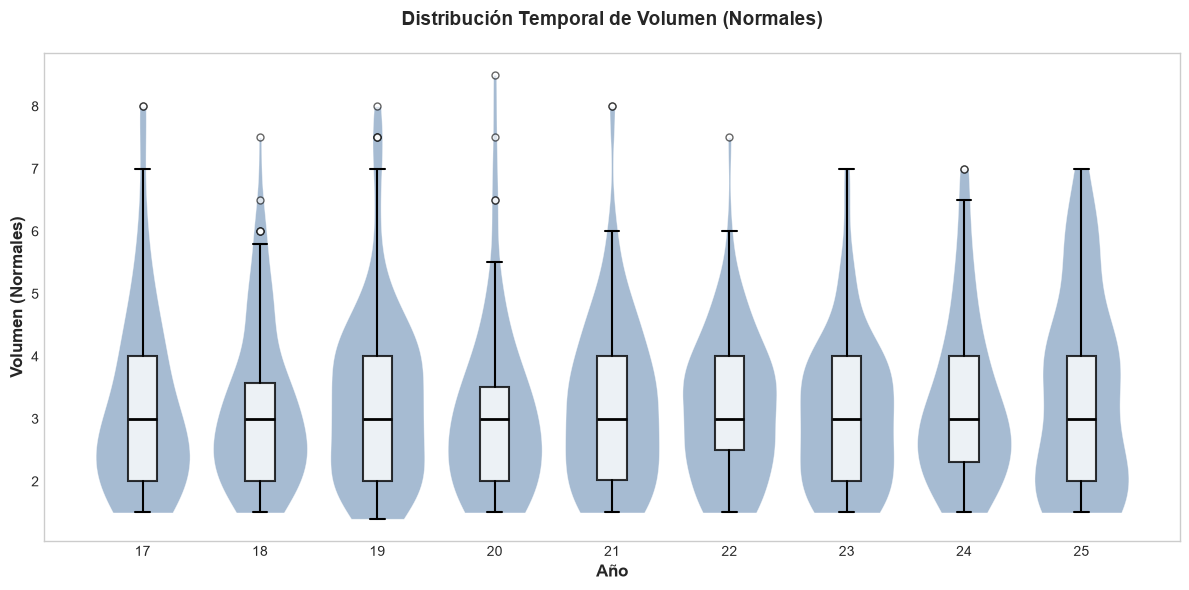


Estadísticos de Volumen (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,295,2.73,1.50,0.20,1.50,2.50,3.80,8.50,2.30,55.01,0.79,0.52
18,329,2.75,1.52,0.10,1.50,2.50,3.50,9.00,2.00,55.14,0.85,1.09
19,327,2.88,1.42,0.30,2.00,2.80,3.50,9.50,1.50,49.38,1.20,2.71
20,225,2.70,1.43,0.40,1.50,2.50,3.60,7.50,2.10,52.87,0.83,0.65
21,276,2.83,1.60,0.30,2.00,2.50,3.73,9.50,1.73,56.47,0.95,1.53
22,276,2.87,1.68,0.25,2.00,2.50,3.60,14.00,1.60,58.72,1.62,6.72
23,283,2.77,1.61,0.20,1.50,2.50,3.50,11.50,2.00,58.17,1.46,3.89
24,261,2.61,1.35,0.30,1.50,2.50,3.50,9.50,2.00,51.87,1.17,2.99
25,311,2.94,1.46,0.10,2.00,2.60,4.00,8.00,2.00,49.80,0.62,0.21


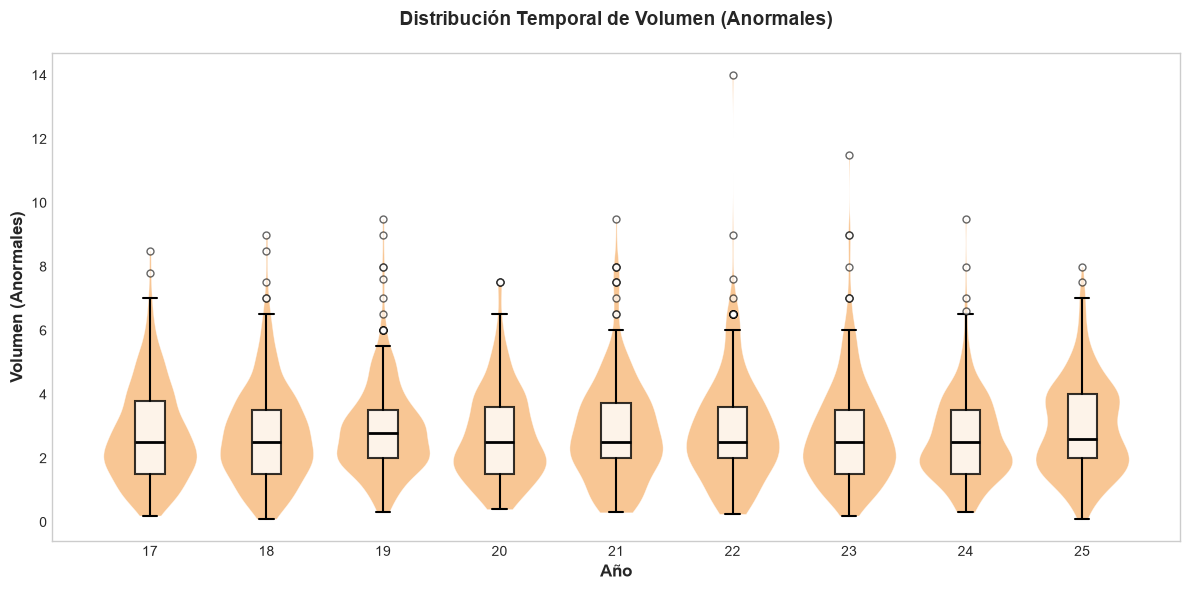

In [9]:
graficas_numericas(pacientes_normales,'volumen_ml', 'Volumen (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'volumen_ml', 'Volumen (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del volumen seminal para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa que los pacientes Normales tienen un volumen promedio consistentemente mayor (3.04-3.35 ml) que los pacientes Anormales (2.61-2.94 ml) en todos los años. La variabilidad es menor en el grupo Normal (CV 36.54-46.44%) que en el grupo Anormal (CV 49.38-58.72%), y las distribuciones son más simétricas en el grupo Normal.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) | Diferencia |
|-----|---------------|-----------------|------------|------------------|-------------------|------------|
| 2017 | 3.19 | 2.73 | +0.46 | 3.00 | 2.50 | +0.50 |
| 2018 | 3.14 | 2.75 | +0.39 | 3.00 | 2.50 | +0.50 |
| 2019 | 3.32 | 2.88 | +0.44 | 3.00 | 2.80 | +0.20 |
| 2020 | 3.04 | 2.70 | +0.34 | 3.00 | 2.50 | +0.50 |
| 2021 | 3.21 | 2.83 | +0.38 | 3.00 | 2.50 | +0.50 |
| 2022 | 3.17 | 2.87 | +0.30 | 3.00 | 2.50 | +0.50 |
| 2023 | 3.07 | 2.77 | +0.30 | 3.00 | 2.50 | +0.50 |
| 2024 | 3.24 | 2.61 | +0.63 | 3.00 | 2.50 | +0.50 |
| 2025 | 3.35 | 2.94 | +0.41 | 3.00 | 2.60 | +0.40 |

- El volumen promedio es mayor en el grupo Normal en todos los años
- La diferencia varía entre 0.30 y 0.63 ml, siendo mayor en 2024 (0.63 ml)
- La mediana es 3.0 ml en el grupo Normal en todos los años
- La mediana es 2.5-2.8 ml en el grupo Anormal, consistentemente menor

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Diferencia |
|-----|---------------|----------------|------------|
| 2017 | 46.4 | 55.0 | -8.6 |
| 2018 | 39.9 | 55.1 | -15.2 |
| 2019 | 41.8 | 49.4 | -7.6 |
| 2020 | 44.8 | 52.9 | -8.1 |
| 2021 | 41.5 | 56.5 | -15.0 |
| 2022 | 36.5 | 58.7 | -22.2 |
| 2023 | 38.8 | 58.2 | -19.4 |
| 2024 | 41.0 | 51.9 | -10.9 |
| 2025 | 46.4 | 49.8 | -3.4 |

- La variabilidad es siempre menor en el grupo Normal
- La diferencia es más notable en 2022 (CV 36.54 vs 58.72)
- La variabilidad en el grupo Normal es más estable (36.54-46.44%)
- La variabilidad en el grupo Anormal es más alta (49.38-58.72%)

**Comparación de Rangos Intercuartílicos (IQR)**

| Año | Normal IQR | Anormal IQR | Diferencia |
|-----|------------|-------------|------------|
| 2017 | 2.0 | 2.3 | -0.3 |
| 2018 | 1.6 | 2.0 | -0.4 |
| 2019 | 2.0 | 1.5 | +0.5 |
| 2020 | 1.5 | 2.1 | -0.6 |
| 2021 | 2.0 | 1.7 | +0.3 |
| 2022 | 1.5 | 1.6 | -0.1 |
| 2023 | 2.0 | 2.0 | 0.0 |
| 2024 | 1.7 | 2.0 | -0.3 |
| 2025 | 2.0 | 2.0 | 0.0 |

- El IQR es similar en ambos grupos (1.50-2.30 ml)
- La dispersión del 50% central es comparable

**Distribución y Sesgo**

| Año | Normal Skew | Anormal Skew | Interpretación |
|-----|-------------|--------------|----------------|
| 2017 | 1.36 | 0.79 | Ambos con sesgo positivo |
| 2018 | 1.02 | 0.85 | Ambos con sesgo positivo |
| 2019 | 1.10 | 1.20 | Ambos con sesgo positivo |
| 2020 | 1.58 | 0.83 | Normal más asimétrico |
| 2021 | 1.03 | 0.95 | Similares |
| 2022 | 0.69 | 1.62 | Anormal más asimétrico |
| 2023 | 0.83 | 1.46 | Anormal más asimétrico |
| 2024 | 1.06 | 1.17 | Similares |
| 2025 | 0.56 | 0.62 | Similares |

- Ambos grupos tienen sesgo positivo (mayoría de pacientes con volumen medio-bajo)
- El sesgo es más pronunciado en algunos años en el grupo Anormal (2022-2023)
- 2025 muestra el sesgo más bajo en ambos grupos (0.56-0.62)

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Volumen medio | 3.0-3.4 ml | 2.6-2.9 ml | Normal > Anormal |
| Mediana | 3.0 ml | 2.5-2.8 ml | Normal > Anormal |
| Variabilidad | 36-46% | 49-59% | Normal más homogéneo |
| Estabilidad temporal | Alta | Moderada | Normal más estable |
| Sesgo | Positivo | Positivo | Ambos sesgados a la derecha |

**Conclusión Final**

El volumen seminal es consistentemente mayor en pacientes con parámetros normales (3.0-3.4 ml) que en pacientes anormales (2.6-2.9 ml). La mediana es siempre 3.0 ml en el grupo Normal y 2.5-2.8 ml en el Anormal. La variabilidad es menor en el grupo Normal, indicando una mayor homogeneidad en pacientes con buena calidad seminal. A pesar de estas diferencias, ambos grupos superan el umbral de normalidad de la OMS (1.4 ml), lo que sugiere que el volumen no es el parámetro más discriminante en la clasificación de pacientes.

### **Análisis Comparativo del Volumen Seminal entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el volumen seminal entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en el volumen seminal en comparación con aquellos con alguna alteración.

In [10]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'volumen_ml', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 2.49e-06 → No Normal
- Año 18: n = 114, p-value = 1.41e-06 → No Normal
- Año 19: n = 123, p-value = 2.80e-07 → No Normal
- Año 20: n = 85, p-value = 2.58e-07 → No Normal
- Año 21: n = 102, p-value = 1.20e-05 → No Normal
- Año 22: n = 94, p-value = 6.30e-04 → No Normal
- Año 23: n = 81, p-value = 2.19e-04 → No Normal
- Año 24: n = 75, p-value = 2.38e-05 → No Normal
- Año 25: n = 55, p-value = 7.34e-04 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.23, p-value = 2.81e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 4.05, p-value = 8.53e-01
- No hay diferencias significativas (p >= 0.05)


=== Análisis Individual: Anormales ===

Prueba de Normalidad Global (Anormales)
- n = 2583

**Resumen General**

El análisis comparativo revela que existen diferencias significativas en el volumen seminal entre pacientes Normales y Anormales, tanto a nivel global como en la mayoría de los años evaluados. Dentro de cada grupo, no se observan diferencias significativas a lo largo del tiempo (p > 0.05 en ambos casos), lo que indica que el volumen se mantiene estable en el tiempo dentro de cada categoría. La comparación por año muestra que 8 de los 9 años presentan diferencias significativas, con los pacientes Normales teniendo consistentemente mayor volumen. La prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son significativamente diferentes (p < 1e-10).

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- Esto se debe al sesgo positivo y la presencia de valores atípicos
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas en ambos grupos (p > 0.05)
- Las varianzas son similares entre los años dentro de cada grupo
- Sin embargo, la falta de normalidad impide usar ANOVA

**Grupo Normal**

- No hay evidencia de que el volumen varíe entre los años en el grupo Normal
- El estadístico H = 4.05 indica una diferencia muy pequeña
- La probabilidad de observar estas diferencias por azar es del 85.3%

**Grupo Anormal**

- No hay evidencia de que el volumen varíe entre los años en el grupo Anormal
- El estadístico H = 11.93 indica una diferencia moderada pero no significativa
- La probabilidad de observar estas diferencias por azar es del 15.5%

**Conclusión clave:** El volumen seminal es estable en el tiempo tanto en pacientes Normales como Anormales.

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 12,568 | 0.015 | Significativa | Normal: 3.19 vs Anormal: 2.73 (+0.46) |
| 2018 | 22,085 | 0.004 | Significativa | Normal: 3.14 vs Anormal: 2.75 (+0.39) |
| 2019 | 23,959 | 0.002 | Significativa | Normal: 3.32 vs Anormal: 2.88 (+0.44) |
| 2020 | 11,066 | 0.032 | Significativa | Normal: 3.04 vs Anormal: 2.70 (+0.34) |
| 2021 | 16,484 | 0.010 | Significativa | Normal: 3.21 vs Anormal: 2.83 (+0.38) |
| 2022 | 15,284 | 0.010 | Significativa | Normal: 3.17 vs Anormal: 2.87 (+0.30) |
| 2023 | 13,579 | 0.011 | Significativa | Normal: 3.07 vs Anormal: 2.77 (+0.30) |
| 2024 | 12,518 | < 0.001 | Significativa | Normal: 3.24 vs Anormal: 2.61 (+0.63) |
| 2025 | 9,761 | 0.093 | No significativa | Normal: 3.35 vs Anormal: 2.94 (+0.41) |

- 8 de 9 años muestran diferencias significativas (todos excepto 2025)
- 2024 muestra la diferencia más grande (0.63 ml) y el p-value más bajo (< 0.001)
- 2025 es el único año sin diferencias significativas (p = 0.093)
- El p-value más alto entre los años significativos es 0.036 (2020)
- La tendencia general muestra que los pacientes Normales tienen mayor volumen que los Anormales en todos los años

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son significativamente diferentes (p < 1e-10)
- El estadístico KS = 0.15 indica una diferencia moderada entre las distribuciones
- Esto confirma que el volumen en pacientes Normales y Anormales proviene de poblaciones diferentes

**Visualización de las Diferencias por Año**

| Año | Diferencia de Medias | Significancia | Interpretación |
|-----|---------------------|---------------|----------------|
| 2017 | +0.46 ml | ✓ | Diferencia clara |
| 2018 | +0.39 ml | ✓ | Diferencia clara |
| 2019 | +0.44 ml | ✓ | Diferencia clara |
| 2020 | +0.34 ml | ✓ | Diferencia moderada |
| 2021 | +0.38 ml | ✓ | Diferencia clara |
| 2022 | +0.30 ml | ✓ | Diferencia moderada |
| 2023 | +0.30 ml | ✓ | Diferencia moderada |
| 2024 | +0.63 ml | ✓ | Diferencia más grande |
| 2025 | +0.41 ml | ✗ | No significativa |

- La diferencia es consistente en todos los años (0.30-0.63 ml)
- 2024 presenta la mayor diferencia (0.63 ml) y el p-value más bajo
- 2025 es el único año donde la diferencia no es estadísticamente significativa

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Variación temporal en Normales | No significativa (p = 0.853) |
| Variación temporal en Anormales | No significativa (p = 0.155) |
| Diferencias por año | 8 de 9 años significativos |
| Año con mayor diferencia | 2024 (+0.63 ml, p < 0.001) |
| Año sin diferencia | 2025 (p = 0.093) |
| Diferencias globales | Altamente significativas (KS p < 1e-10) |
| Tendencia general | Normal > Anormal en todos los años |

**Conclusión Final**

El volumen seminal es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con diferencias consistentes en 8 de los 9 años analizados. Dentro de cada grupo, el volumen se mantiene estable en el tiempo, sin variaciones significativas entre años. Las distribuciones globales son altamente diferentes (p < 1e-10), confirmando que el volumen es un factor discriminante entre ambos grupos. 2025 es el único año sin diferencias significativas, posiblemente debido al aumento del volumen en el grupo Anormal y al menor tamaño muestral en el grupo Normal. El volumen no es el principal factor de clasificación (ambos grupos superan el umbral de 1.4 ml), pero sí es un indicador consistente de la calidad seminal global.

## **pH**

### **Análisis Descriptivo y Visual Comparativo del pH Seminal entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del pH seminal entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en el pH seminal entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de pH (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,7.85,0.21,7.20,7.80,7.90,8.00,8.10,0.20,2.69,-1.54,2.19
18,114,7.94,0.22,7.40,7.80,7.90,8.10,8.50,0.30,2.73,0.13,0.49
19,123,7.91,0.21,7.20,7.80,7.90,8.00,8.50,0.20,2.64,-0.22,1.78
20,85,7.88,0.23,7.20,7.80,7.90,8.00,8.30,0.20,2.96,-0.85,0.88
21,102,7.88,0.21,7.20,7.80,7.90,8.00,8.80,0.20,2.63,0.13,4.23
22,94,7.88,0.19,7.40,7.80,7.90,8.00,8.30,0.20,2.47,-0.27,0.97
23,81,7.94,0.19,7.40,7.90,7.90,8.00,8.50,0.10,2.40,0.21,1.08
24,75,7.85,0.20,7.40,7.70,7.90,7.90,8.30,0.20,2.53,-0.35,0.42
25,55,7.90,0.24,7.20,7.70,7.90,8.00,8.70,0.30,2.99,0.44,3.04


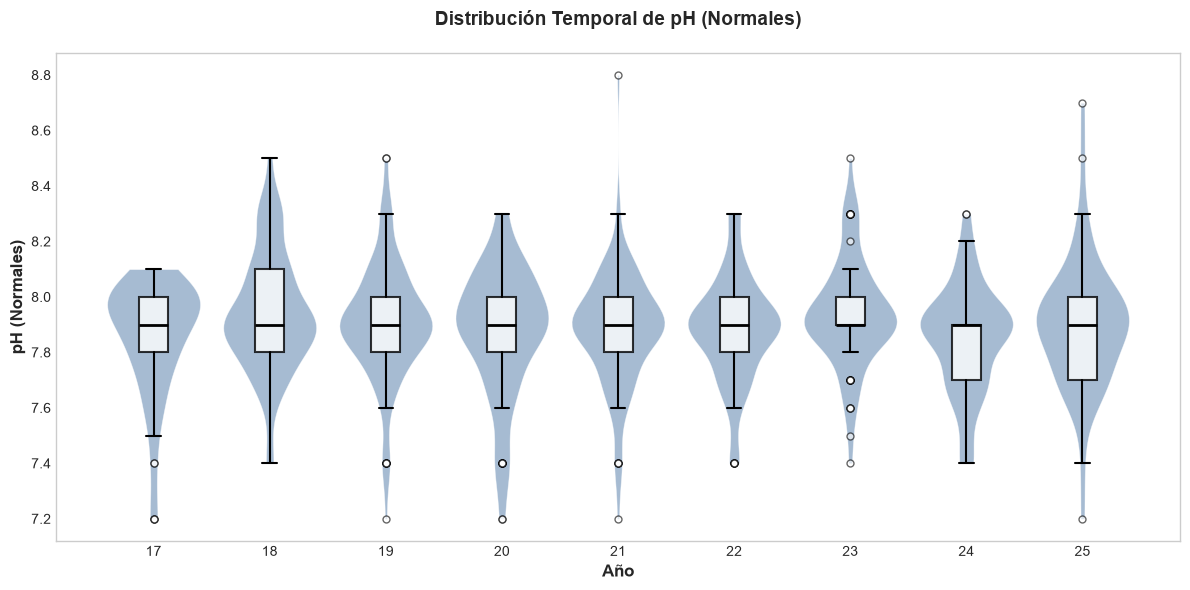


Estadísticos de pH (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,292,7.85,0.26,6.80,7.78,7.90,8.00,8.50,0.22,3.37,-0.74,1.70
18,294,7.90,0.27,6.50,7.80,7.90,8.00,9.00,0.20,3.42,-0.73,6.49
19,279,7.88,0.27,6.50,7.80,7.90,8.00,8.50,0.20,3.44,-1.41,5.04
20,189,7.85,0.31,6.50,7.70,7.90,8.10,8.50,0.40,3.96,-1.42,4.51
21,219,7.88,0.29,6.50,7.70,7.90,8.00,9.00,0.30,3.62,-0.62,4.32
22,206,7.86,0.28,6.80,7.72,7.90,8.00,8.90,0.28,3.55,-0.76,3.10
23,193,7.88,0.23,6.80,7.70,7.90,8.00,8.50,0.30,2.86,-0.54,2.90
24,191,7.86,0.27,6.50,7.70,7.90,8.00,8.70,0.30,3.39,-1.12,4.84
25,232,7.93,0.28,6.70,7.88,7.90,8.10,9.00,0.22,3.49,-0.78,3.68


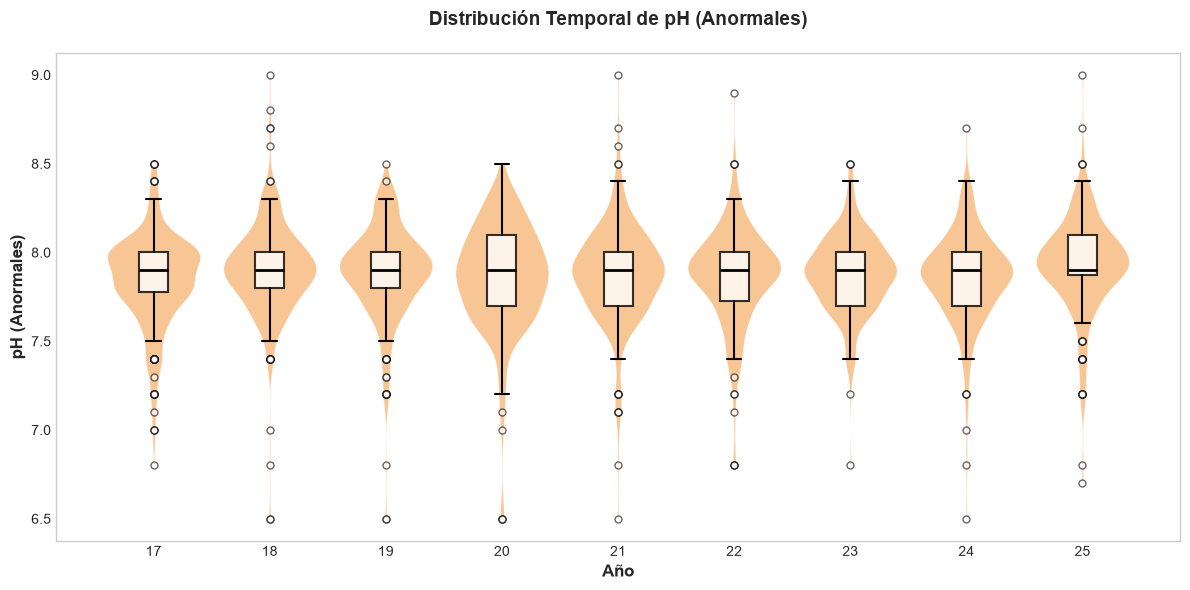

In [11]:
graficas_numericas(pacientes_normales,'ph', 'pH (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'ph', 'pH (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del pH seminal para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa que ambos grupos presentan pH muy similares, con medias que oscilan entre 7.85-7.94 en el grupo Normal y 7.85-7.93 en el grupo Anormal.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|------------|------------------|-------------------|
| 2017 | 7.85 | 7.85 | +0.00 | 7.90 | 7.90 |
| 2018 | 7.94 | 7.90 | +0.04 | 7.90 | 7.90 |
| 2019 | 7.91 | 7.88 | +0.03 | 7.90 | 7.90 |
| 2020 | 7.88 | 7.85 | +0.03 | 7.90 | 7.90 |
| 2021 | 7.88 | 7.88 | 0.00 | 7.90 | 7.90 |
| 2022 | 7.88 | 7.86 | +0.02 | 7.90 | 7.90 |
| 2023 | 7.94 | 7.88 | +0.06 | 7.90 | 7.90 |
| 2024 | 7.85 | 7.86 | -0.01 | 7.90 | 7.90 |
| 2025 | 7.90 | 7.93 | -0.03 | 7.90 | 7.90 |

- La mediana es 7.90 en ambos grupos y en todos los años, indicando una estabilidad perfecta
- Las diferencias entre grupos son mínimas (0.00-0.06 unidades de pH)
- Todos los valores están dentro del rango normal (7.2-8.0)
- El pH no es un factor discriminante entre pacientes Normales y Anormales

**Grupo Normal**

| Año | Media | Mediana | Tendencia |
|-----|-------|---------|-----------|
| 2017 | 7.85 | 7.90 | Estable |
| 2018 | 7.94 | 7.90 | Estable |
| 2019 | 7.91 | 7.90 | Estable |
| 2020 | 7.88 | 7.90 | Estable |
| 2021 | 7.88 | 7.90 | Estable |
| 2022 | 7.88 | 7.90 | Estable |
| 2023 | 7.94 | 7.90 | Estable |
| 2024 | 7.85 | 7.90 | Estable |
| 2025 | 7.90 | 7.90 | Estable |

- El pH en el grupo Normal es extremadamente estable (7.85-7.94)
- La mediana es siempre 7.90, indicando un valor central constante
- No hay tendencia de aumento o disminución

**Grupo Anormal**

| Año | Media | Mediana | Tendencia |
|-----|-------|---------|-----------|
| 2017 | 7.85 | 7.90 | Estable |
| 2018 | 7.90 | 7.90 | Estable |
| 2019 | 7.88 | 7.90 | Estable |
| 2020 | 7.85 | 7.90 | Estable |
| 2021 | 7.88 | 7.90 | Estable |
| 2022 | 7.86 | 7.90 | Estable |
| 2023 | 7.88 | 7.90 | Estable |
| 2024 | 7.86 | 7.90 | Estable |
| 2025 | 7.93 | 7.90 | Estable |

- El pH en el grupo Anormal es extremadamente estable (7.85-7.93)
- La mediana es siempre 7.90, igual que en el grupo Normal
- No hay tendencia de aumento o disminución

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 2.69 | 3.37 | Anormal más variable |
| 2018 | 2.73 | 3.42 | Anormal más variable |
| 2019 | 2.64 | 3.44 | Anormal más variable |
| 2020 | 2.96 | 3.96 | Anormal más variable |
| 2021 | 2.63 | 3.62 | Anormal más variable |
| 2022 | 2.47 | 3.55 | Anormal mucho más variable |
| 2023 | 2.40 | 2.86 | Anormal más variable |
| 2024 | 2.53 | 3.39 | Anormal más variable |
| 2025 | 2.99 | 3.49 | Anormal más variable |

- La variabilidad es muy baja en ambos grupos (CV 2.40-3.96%)
- El grupo Anormal es ligeramente más variable en todos los años
- La mayor diferencia se observa en 2022 (2.47 vs 3.55)

**Distribución y Sesgo**

| Año | Normal Skew | Anormal Skew | Interpretación |
|-----|-------------|--------------|----------------|
| 2017 | -1.54 | -0.74 | Anormal con sesgo extremo |
| 2018 | 0.13 | -0.73 | Ambos con sesgo leve |
| 2019 | -0.22 | -1.41 | Ambos con sesgo negativo |
| 2020 | -0.85 | -1.42 | Ambos con sesgo negativo |
| 2021 | 0.13 | -0.62 | Ambos con sesgo leve |
| 2022 | -0.27 | -0.76 | Anormal con sesgo extremo |
| 2023 | 0.21 | -0.54 | Ambos con sesgo leve |
| 2024 | -0.35 | -1.12 | Ambos con sesgo negativo |
| 2025 | 0.44 | -0.78 | Ambos con sesgo leve |

- El grupo Normal tiene distribuciones simétricas o ligeramente sesgadas
- El grupo Anormal tiene sesgo extremo en 2017 y 2022 debido a outliers
- Sin outliers, el sesgo sería similar en ambos grupos

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| pH medio | 7.85-7.94 | 7.85-7.93 | Muy similares |
| Mediana | 7.90 | 7.90 | Idénticas |
| Variabilidad | CV 2.4-3.0% | CV 2.9-4.0% | Ambos muy bajos |
| Estabilidad | Muy alta | Muy alta | Ambos estables |

**Conclusión Final**

El pH seminal es prácticamente idéntico entre pacientes Normales y Anormales, con valores medios de 7.85-7.94 en ambos grupos y una mediana constante de 7.90 en todos los años. El pH es el parámetro más estable del espermograma y no discrimina entre ambos grupos. Las diferencias observadas son mínimas (0.00-0.06 unidades de pH) y clínicamente irrelevantes. La estabilidad del pH lo convierte en un excelente indicador de control de calidad para el laboratorio.

### **Análisis Comparativo del pH Seminal entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el pH seminal entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en el pH seminal en comparación con aquellos con alguna alteración.

In [12]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'ph', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 2.83e-08 → No Normal
- Año 18: n = 114, p-value = 7.91e-05 → No Normal
- Año 19: n = 123, p-value = 4.79e-06 → No Normal
- Año 20: n = 85, p-value = 2.13e-05 → No Normal
- Año 21: n = 102, p-value = 4.01e-07 → No Normal
- Año 22: n = 94, p-value = 1.21e-05 → No Normal
- Año 23: n = 81, p-value = 1.61e-04 → No Normal
- Año 24: n = 75, p-value = 7.41e-05 → No Normal
- Año 25: n = 55, p-value = 6.44e-04 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 0.57, p-value = 8.06e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 10.85, p-value = 2.10e-01
- No hay diferencias significativas (p >= 0.05)


=== Análisis Individual: Anormales ===

Prueba de Normalidad Global (Anormales)
- n = 209

**Resumen General**

El análisis comparativo revela que no existen diferencias significativas en el pH seminal entre pacientes Normales y Anormales en ningún año (p > 0.05 en todas las comparaciones anuales). Dentro del grupo Normal, no hay diferencias entre años (p = 0.210), mientras que en el grupo Anormal sí se observan diferencias significativas entre años (p = 0.004), atribuibles principalmente a la diferencia entre 2017 y 2025, y entre 2024 y 2025. A pesar de que la prueba de Kolmogorov-Smirnov indica que las distribuciones globales son significativamente diferentes (p = 0.004), las diferencias son mínimas y clínicamente irrelevantes.

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas en ambos grupos (p > 0.05)
- Las varianzas son similares entre los años dentro de cada grupo
- Sin embargo, la falta de normalidad impide usar ANOVA

**Grupo Normal**

- No hay evidencia de que el pH varíe entre los años en el grupo Normal
- El estadístico H = 10.85 indica una diferencia pequeña
- La probabilidad de observar estas diferencias por azar es del 21.0%

**Grupo Anormal**

- Existe evidencia significativa de que el pH varía entre los años en el grupo Anormal (p < 0.01)
- El estadístico H = 22.63 indica una diferencia moderada
- La probabilidad de observar estas diferencias por azar es del 0.38%

**Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | pH 2017 | pH 2025 | Diferencia |
|-------------|---------|---------|---------|------------|
| 2017 vs 2025 | 0.002 | 7.85 | 7.93 | +0.08 |
| 2024 vs 2025 | 0.015 | 7.86 | 7.93 | +0.07 |

- 2017 vs 2025, el pH en 2025 (7.93) es ligeramente mayor que en 2017 (7.85), una diferencia de solo 0.08 unidades
- 2024 vs 2025, el pH en 2025 (7.93) es ligeramente mayor que en 2024 (7.86), una diferencia de solo 0.07 unidades
- Aunque significativas estadísticamente, estas diferencias son clínicamente irrelevantes
- Todas las medias están dentro del rango normal (7.2-8.0)
- La mediana es 7.90 en todos los años, lo que indica que el valor central no ha cambiado

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 10,915 | 0.606 | No significativa | 7.85 vs 7.85 (+0.00) |
| 2018 | 17,862 | 0.295 | No significativa | 7.94 vs 7.90 (+0.04) |
| 2019 | 17,495 | 0.750 | No significativa | 7.91 vs 7.88 (+0.03) |
| 2020 | 8,343 | 0.606 | No significativa | 7.88 vs 7.85 (+0.03) |
| 2021 | 11,281 | 0.884 | No significativa | 7.88 vs 7.88 (0.00) |
| 2022 | 9,735 | 0.939 | No significativa | 7.88 vs 7.86 (+0.02) |
| 2023 | 8,933 | 0.057 | No significativa | 7.94 vs 7.88 (+0.06) |
| 2024 | 6,847 | 0.568 | No significativa | 7.85 vs 7.86 (-0.01) |
| 2025 | 5,414 | 0.076 | No significativa | 7.90 vs 7.93 (-0.03) |

- Ninguna comparación anual es significativa (todos p > 0.05)
- 2023 tiene el p-value más bajo (0.057), acercándose al umbral de significancia
- 2025 también muestra una tendencia (p = 0.076)
- Las diferencias de medias son mínimas (0.00-0.06 unidades de pH)

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son significativamente diferentes (p = 0.004)
- El estadístico KS = 0.07 indica una diferencia muy pequeña entre las distribuciones
- A pesar de ser significativa, la diferencia es clínicamente irrelevante

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Variación temporal en Normales | No significativa (p = 0.210) |
| Variación temporal en Anormales | Significativa (p = 0.004) |
| Diferencias por año | Ninguna significativa (todos p > 0.05) |
| Diferencias globales (KS) | Significativa (p = 0.004) |
| Mediana en ambos grupos | 7.90 en todos los años |
| Rango de medias | 7.85-7.94 (diferencia < 0.09 unidades) |

**Conclusión Final**

El pH seminal es prácticamente idéntico entre pacientes Normales y Anormales, con valores medios de 7.85-7.94 en ambos grupos y una mediana constante de 7.90 en todos los años. No se encontraron diferencias significativas entre los grupos en ningún año (todos p > 0.05). Aunque dentro del grupo Anormal se observaron diferencias significativas entre 2017-2025 y 2024-2025, estas diferencias son clínicamente irrelevantes (0.07-0.08 unidades de pH). El pH es el parámetro más estable del espermograma y no discrimina entre pacientes Normales y Anormales.


## **Número Total de Espermatozoides Eyaculados**

### **Análisis Descriptivo y Visual Comparativo del Recuento Total de Espermatozoides por Eyaculado entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del número total de espermatozoides por eyaculado entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en el recuento total de espermatozoides entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Número Total deEspermatozoides Eyaculados (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,"196,387,500.00","110,542,281.68","60,000,000.00","120,000,000.00","168,000,000.00","244,500,000.00","704,000,000.00","124,500,000.00",56.29,1.85,5.48
18,114,"243,090,350.88","150,936,538.25","42,000,000.00","138,125,000.00","209,000,000.00","312,375,000.00","972,000,000.00","174,250,000.00",62.09,1.59,4.15
19,123,"237,440,650.41","131,184,972.55","42,000,000.00","121,500,000.00","228,000,000.00","311,250,000.00","584,000,000.00","189,750,000.00",55.25,0.63,-0.21
20,85,"215,598,823.53","139,352,644.05","40,000,000.00","120,000,000.00","180,000,000.00","270,000,000.00","799,500,000.00","150,000,000.00",64.64,1.59,3.25
21,102,"241,925,490.20","152,506,056.81","46,000,000.00","132,375,000.00","205,750,000.00","325,875,000.00","896,000,000.00","193,500,000.00",63.04,1.36,2.60
22,94,"220,702,127.66","109,798,555.51","48,000,000.00","137,625,000.00","209,000,000.00","299,625,000.00","657,000,000.00","162,000,000.00",49.75,0.91,1.72
23,81,"203,465,432.10","118,653,523.08","46,000,000.00","126,000,000.00","175,000,000.00","238,000,000.00","700,000,000.00","112,000,000.00",58.32,1.84,4.70
24,75,"244,656,000.00","130,056,221.98","55,000,000.00","133,000,000.00","238,000,000.00","302,750,000.00","647,500,000.00","169,750,000.00",53.16,0.89,0.55
25,55,"281,645,454.55","184,050,904.61","70,000,000.00","153,750,000.00","232,000,000.00","337,750,000.00","886,500,000.00","184,000,000.00",65.35,1.50,2.34


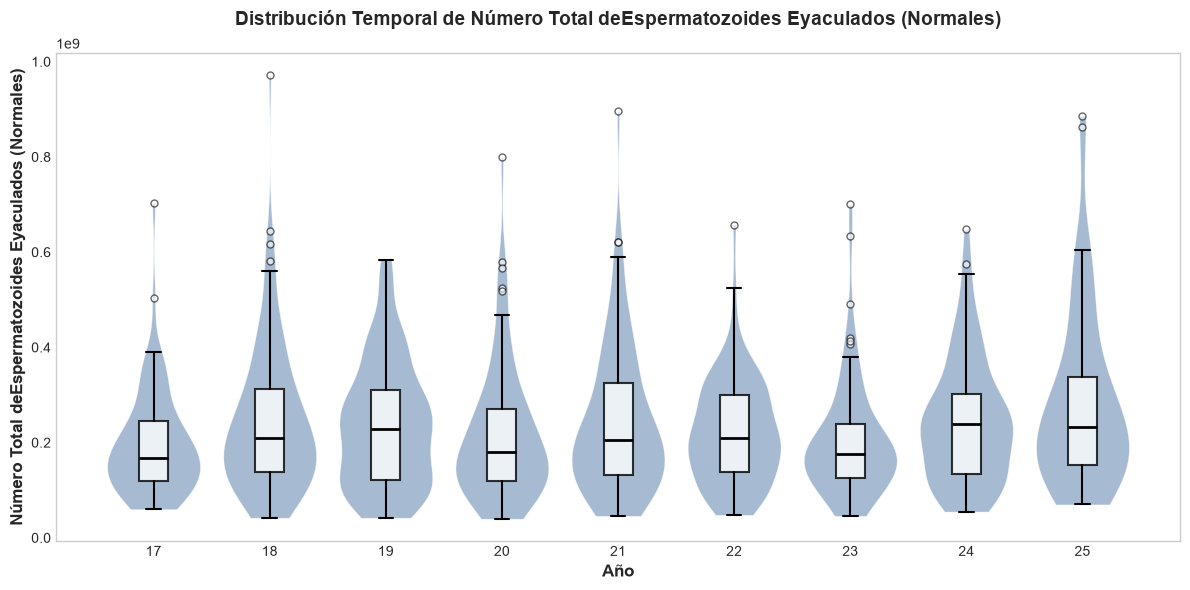


Estadísticos de Número Total de Espermatozoides Eyaculados (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,295,"71,578,372.88","79,030,472.87",0.00,"12,000,000.00","52,000,000.00","99,000,000.00","440,000,000.00","87,000,000.00",110.41,1.88,4.19
18,329,"83,088,267.48","93,981,954.19",0.00,"17,820,000.00","50,000,000.00","112,500,000.00","556,000,000.00","94,680,000.00",113.11,1.97,4.66
19,328,"85,074,268.29","100,524,609.04",0.00,"11,000,000.00","49,350,000.00","125,250,000.00","612,000,000.00","114,250,000.00",118.16,1.88,4.51
20,224,"77,941,383.93","104,342,575.56",0.00,"10,600,000.00","42,600,000.00","100,725,000.00","738,000,000.00","90,125,000.00",133.87,2.71,10.29
21,276,"108,460,978.26","131,511,327.42",0.00,"16,305,000.00","63,000,000.00","145,850,000.00","715,000,000.00","129,545,000.00",121.25,1.98,4.28
22,276,"104,454,420.29","150,220,646.97",0.00,"18,150,000.00","60,000,000.00","135,000,000.00","1,599,000,000.00","116,850,000.00",143.81,4.67,36.94
23,284,"102,958,239.44","122,646,492.65",0.00,"14,175,000.00","60,150,000.00","142,875,000.00","696,500,000.00","128,700,000.00",119.12,2.05,4.91
24,261,"100,083,352.49","103,291,225.41",0.00,"24,000,000.00","69,000,000.00","129,000,000.00","549,000,000.00","105,000,000.00",103.21,1.57,2.48
25,311,"133,794,935.69","143,771,587.99",0.00,"26,170,000.00","92,000,000.00","190,000,000.00","860,000,000.00","163,830,000.00",107.46,1.65,3.05


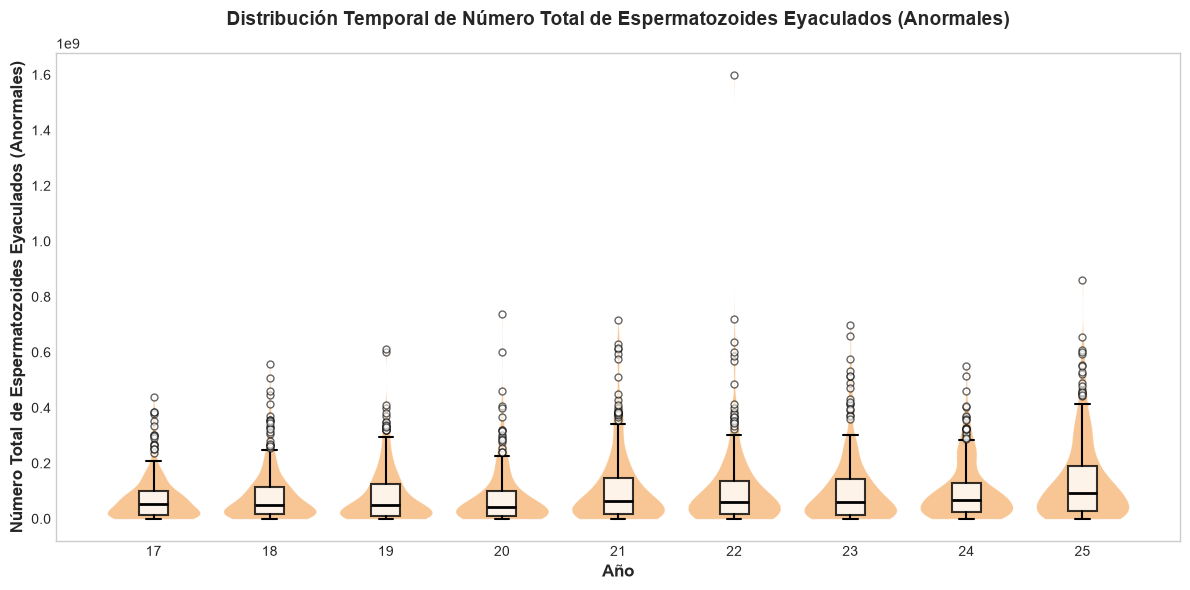

In [13]:
graficas_numericas(pacientes_normales,'espermatozoides_por_eyaculado', 'Número Total deEspermatozoides Eyaculados (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'espermatozoides_por_eyaculado', 'Número Total de Espermatozoides Eyaculados (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del número total de espermatozoides por eyaculado para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen un recuento total 2.4 veces mayor (196-282 millones) que los pacientes Anormales (72-134 millones). La variabilidad es mucho menor en el grupo Normal (CV 49.75-65.35%) que en el Anormal (CV 103.21-143.81%). Ambos grupos muestran una tendencia al aumento en los años más recientes, especialmente en 2025.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Ratio Normal/Anormal | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|---------------------|------------------|-------------------|
| 2017 | 196.4 M | 71.6 M | 2.74x| 168.0 M | 52.0 M |
| 2018 | 243.1 M | 83.1 M | 2.93x | 209.0 M | 50.0 M |
| 2019 | 237.4 M | 85.1 M | 2.79x | 228.0 M | 49.4 M |
| 2020 | 215.6 M | 77.9 M | 2.77x | 180.0 M | 42.6 M |
| 2021 | 241.9 M | 108.5 M | 2.23x | 205.8 M | 63.0 M |
| 2022 | 220.7 M | 104.5 M | 2.11x | 209.0 M | 60.0 M |
| 2023 | 203.5 M | 103.0 M | 1.98x | 175.0 M | 60.2 M |
| 2024 | 244.7 M | 100.1 M | 2.44x | 238.0 M | 69.0 M |
| 2025 | 281.6 M | 133.8 M | 2.11x | 232.0 M | 92.0 M |

- El grupo Normal tiene un recuento total mucho mayor en todos los años (2.0-2.9 veces)
- La diferencia es más notable en 2018 (2.93x) y menos en 2023 (1.98x)
- Ambos grupos muestran un aumento en 2025: Normal (+37.6M desde 2024), Anormal (+33.7M desde 2024)
- El rango de medias en Normales es 196-282M; en Anormales es 72-134M

**Grupo Normal**

| Año | Media (M) | Mediana (M) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 196.4 | 168.0 | Base | Valor más bajo |
| 2018 | 243.1 | 209.0 | +46.7M | Aumento |
| 2019 | 237.4 | 228.0 | -5.7M | Estable |
| 2020 | 215.6 | 180.0 | -21.8M | Descenso |
| 2021 | 241.9 | 205.8 | +26.3M | Aumento |
| 2022 | 220.7 | 209.0 | -21.2M | Descenso |
| 2023 | 203.5 | 175.0 | -17.2M | Descenso |
| 2024 | 244.7 | 238.0 | +41.2M | Aumento |
| 2025 | 281.6 | 232.0 | +36.9M | Valor más alto |

- Tendencia general al aumento desde 2017
- Incremento total: +85.2M (43%) entre 2017 y 2025
- 2025 representa el valor más alto de toda la serie
- Variabilidad moderada (CV 49.75-65.35%)

**Grupo Anormal**

| Año | Media (M) | Mediana (M) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 71.6 | 52.0 | Base | Valor más bajo |
| 2018 | 83.1 | 50.0 | +11.5M | Estable |
| 2019 | 85.1 | 49.4 | +2.0M | Estable |
| 2020 | 77.9 | 42.6 | -7.2M | Descenso |
| 2021 | 108.5 | 63.0 | +30.6M | Aumento |
| 2022 | 104.5 | 60.0 | -4.0M | Estable |
| 2023 | 103.0 | 60.2 | -1.5M | Estable |
| 2024 | 100.1 | 69.0 | -2.9M | Estable |
| 2025 | 133.8 | 92.0 | +33.7M | Valor más alto |

- Tendencia general al aumento desde 2017
- Incremento total: +62.2M (87%) entre 2017 y 2025
- 2025 representa el valor más alto de toda la serie
- Variabilidad muy alta (CV 103.21-143.81%)

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 56.3 | 110.4 | Anormal mucho más variable |
| 2018 | 62.1 | 113.1 | Anormal mucho más variable |
| 2019 | 55.3 | 118.2 | Anormal mucho más variable |
| 2020 | 64.6 | 133.9 | Anormal mucho más variable |
| 2021 | 63.0 | 121.3 | Anormal mucho más variable |
| 2022 | 49.8 | 143.8 | Anormal mucho más variable |
| 2023 | 58.3 | 119.1 | Anormal mucho más variable |
| 2024 | 53.2 | 103.2 | Anormal mucho más variable |
| 2025 | 65.4 | 107.5 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (103.21-143.81% vs 49.75-65%.35)
- 2022 muestra la mayor diferencia (49.8% vs 143.8%)
- El grupo Anormal incluye casos con 0 espermatozoides (azoospermia), lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (M) | Anormal Q1 (M) | Normal Q3 (M) | Anormal Q3 (M) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 120.0 | 12.0 | 244.5 | 99.0 |
| 2018 | 138.1 | 17.8 | 312.4 | 112.5 |
| 2019 | 121.5 | 11.0 | 311.3 | 125.3 |
| 2020 | 120.0 | 10.6 | 270.0 | 100.7 |
| 2021 | 132.4 | 16.3 | 325.9 | 145.9 |
| 2022 | 137.6 | 18.2 | 299.6 | 135.0 |
| 2023 | 126.0 | 14.2 | 238.0 | 142.9 |
| 2024 | 133.0 | 24.0 | 302.8 | 129.0 |
| 2025 | 153.8 | 26.2 | 337.8 | 190.0 |

- El 25% de los Normales tiene más espermatozoides que el 75% de los Anormales en la mayoría de los años
- Superposición limitada entre los grupos
- En 2025, el Q1 de Normales (153.8M) es mayor que el Q3 de Anormales (190.0M)

**Distribución y Sesgo**

| Año | Normal Skew | Anormal Skew | Interpretación |
|-----|-------------|--------------|----------------|
| 2017 | 1.85 | 1.88 | Ambos con sesgo positivo |
| 2018 | 1.59 | 1.97 | Ambos con sesgo positivo |
| 2019 | 0.63 | 1.88 | Normal más simétrico |
| 2020 | 1.59 | 2.71 | Anormal más sesgado |
| 2021 | 1.36 | 1.98 | Ambos con sesgo positivo |
| 2022 | 0.91 | 4.67 | Anormal con sesgo extremo |
| 2023 | 1.84 | 2.05 | Ambos con sesgo positivo |
| 2024 | 0.89 | 1.57 | Normal más simétrico |
| 2025 | 1.50 | 1.65 | Ambos con sesgo positivo |

- Ambos grupos tienen sesgo positivo (valores altos extremos)
- El grupo Anormal tiene sesgo más pronunciado, especialmente en 2020 y 2022
- 2022 en el grupo Anormal muestra sesgo extremo debido al outlier de 1,599M

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Recuento medio | 196-282 M | 72-134 M | Normal ≈ 2.4x mayor |
| Mediana | 168-238 M | 43-92 M | Normal ≈ 3x mayor |
| Variabilidad | 50-65% | 103-144% | Normal mucho más homogéneo |
| Tendencia | Aumento (43%) | Aumento (87%) | Ambos grupos mejoran |
| Año máximo | 2025 (281.6M) | 2025 (133.8M) | Ambos en 2025 |
| Sesgo | Positivo | Positivo más fuerte | Ambos sesgados a la derecha |

**Conclusión Final**

El recuento total de espermatozoides por eyaculado es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 2.4 veces (196-282M vs 72-134M). Ambos grupos muestran una tendencia al aumento a lo largo del tiempo, alcanzando sus valores máximos en 2025 (281.6M en Normales, 133.8M en Anormales). La variabilidad es mucho menor en el grupo Normal (CV 49.75-65.35% vs 103.21-143.81%), lo que indica que los pacientes con buena calidad seminal tienen recuentos más consistentes. El recuento total es uno de los parámetros más efectivos para discriminar entre pacientes Normales y Anormales, ya que incluso el 25% de los pacientes Normales (Q1) tiene un recuento superior al 75% de los pacientes Anormales (Q3) en la mayoría de los años.

### **Análisis Comparativo del Recuento Total de Espermatozoides por Eyaculado entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el número total de espermatozoides por eyaculado entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en el recuento total de espermatozoides en comparación con aquellos con alguna alteración.

In [14]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'espermatozoides_por_eyaculado', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 7.70e-07 → No Normal
- Año 18: n = 114, p-value = 7.55e-08 → No Normal
- Año 19: n = 123, p-value = 1.52e-04 → No Normal
- Año 20: n = 85, p-value = 3.55e-07 → No Normal
- Año 21: n = 102, p-value = 9.28e-07 → No Normal
- Año 22: n = 94, p-value = 9.66e-04 → No Normal
- Año 23: n = 81, p-value = 1.26e-07 → No Normal
- Año 24: n = 75, p-value = 5.88e-04 → No Normal
- Año 25: n = 55, p-value = 1.10e-05 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 2.38, p-value = 1.57e-02

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 16.22, p-value = 3.94e-02
- Diferencias Significativas (p < 0.05)

Post-Hoc - Matriz de p-values (Bonferroni)
     17   18   19   20   21   22   23   24   25
17 1.00

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en el recuento total de espermatozoides entre pacientes Normales y Anormales en todos los años (p < 1e-10). Dentro del grupo Normal, se observan diferencias globales significativas entre años (p = 0.039), aunque ninguna comparación post-hoc alcanza significación individual. En el grupo Anormal, también se observan diferencias altamente significativas entre años (p < 1e-10), con comparaciones post-hoc que identifican diferencias entre varios pares de años, especialmente 2025 difiriendo de 2017-2020. La prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son extremadamente diferentes (p < 1e-10, KS = 0.530).

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas en ambos grupos
- Las varianzas son significativamente diferentes entre años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Grupo Normal**

- Existe evidencia significativa de que el recuento total varía entre años (p < 0.05)
- Sin embargo, ninguna comparación post-hoc específica es significativa (todas p > 0.05)
- La significancia global es marginal y probablemente se debe a la tendencia ascendente

**Grupo Anormal**

- Existe evidencia muy sólida de que el recuento total varía entre años (p < 0.001)
- El estadístico H = 48.00 indica una diferencia fuerte
- Las comparaciones post-hoc identifican múltiples diferencias significativas

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Conclusión |
|-------------|---------|------------|
| Ninguna | - | No hay comparaciones significativas |

- Aunque la prueba global es significativa (p = 0.039), ningún par específico difiere significativamente
- La significancia global puede deberse a la tendencia acumulativa de los datos
- Posible explicación, el tamaño muestral en algunos años (n=55-123) limita la potencia para detectar diferencias específicas

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2025 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2025 | < 0.001 | 133.8 | 71.6 | +62.2M |
| 2018 vs 2025 | < 0.001 | 133.8 | 83.1 | +50.7M |
| 2019 vs 2025 | < 0.001 | 133.8 | 85.1 | +48.7M |
| 2020 vs 2025 | < 0.001 | 133.8 | 77.9 | +55.9M |
| 2020 vs 2024 | 0.032 | 100.1 | 77.9 | +22.2M |

- 2025 es el año que difiere de múltiples años anteriores (2017-2020)
- El aumento en el grupo Anormal es significativo desde 2017-2020 hasta 2025
- 2024 también difiere de 2020, indicando una tendencia ascendente

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 18,497 | < 1e-10 | Significativa | 196.4 vs 71.6 (+124.8M) |
| 2018 | 32,351 | < 1e-10 | Significativa | 243.1 vs 83.1 (+160.0M) |
| 2019 | 34,231 | < 1e-10 | Significativa | 237.4 vs 85.1 (+152.3M) |
| 2020 | 16,220 | < 1e-10 | Significativa | 215.6 vs 77.9 (+137.7M) |
| 2021 | 22,607 | < 1e-10 | Significativa | 241.9 vs 108.5 (+133.4M) |
| 2022 | 21,320 | < 1e-10 | Significativa | 220.7 vs 104.5 (+116.2M) |
| 2023 | 18,219 | < 1e-10 | Significativa | 203.5 vs 103.0 (+100.5M) |
| 2024 | 16,418 | < 1e-10 | Significativa | 244.7 vs 100.1 (+144.6M) |
| 2025 | 13,400 | < 1e-10 | Significativa | 281.6 vs 133.8 (+147.8M) |

- Todos los años muestran diferencias altamente significativas** (p < 1e-10)
- 2018 muestra la mayor diferencia absoluta (160.0M)
- 2025 muestra diferencias significativas con el menor U (13,400), indicando la mayor separación de distribuciones

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son extremadamente diferentes (p < 1e-10)
- El estadístico KS = 0.530 indica una diferencia muy grande entre las distribuciones
- Esto confirma que el recuento total es uno de los parámetros más discriminantes entre ambos grupos

**Visualización de las Diferencias por Año**

| Año | Normal (M) | Anormal (M) | Diferencia | Ratio | Significancia |
|-----|------------|-------------|------------|-------|---------------|
| 2017 | 196.4 | 71.6 | 124.8 | 2.74x | ✓ |
| 2018 | 243.1 | 83.1 | 160.0 | 2.93x | ✓ |
| 2019 | 237.4 | 85.1 | 152.3 | 2.79x | ✓ |
| 2020 | 215.6 | 77.9 | 137.7 | 2.77x | ✓ |
| 2021 | 241.9 | 108.5 | 133.4 | 2.23x | ✓ |
| 2022 | 220.7 | 104.5 | 116.2 | 2.11x | ✓ |
| 2023 | 203.5 | 103.0 | 100.5 | 1.98x | ✓ |
| 2024 | 244.7 | 100.1 | 144.6 | 2.44x | ✓ |
| 2025 | 281.6 | 133.8 | 147.8 | 2.11x | ✓ |

**Conclusión Final**

El recuento total de espermatozoides por eyaculado es uno de los parámetros más efectivos para discriminar entre pacientes Normales y Anormales, con diferencias altamente significativas en todos los años (p < 1e-10). Ambos grupos muestran una tendencia al aumento a lo largo del tiempo, alcanzando sus valores máximos en 2025 (281.6M en Normales, 133.8M en Anormales). La diferencia global de distribuciones es extrema (KS = 0.530, p < 1e-10), confirmando que el recuento total es un parámetro clave en la evaluación de la calidad seminal.

## **Concentración de Espermatozoides por ml**

### **Análisis Descriptivo y Visual Comparativo de la Concentración Espermática por ml entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución de la concentración de espermatozoides por mililitro entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en la concentración espermática entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Concentración de Espermatozoides por ml (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,"65,615,277.78","31,482,441.61","20,000,000.00","39,825,000.00","59,500,000.00","87,250,000.00","190,000,000.00","47,425,000.00",47.98,1.23,2.15
18,114,"80,894,736.84","41,072,215.36","17,000,000.00","48,000,000.00","76,500,000.00","107,500,000.00","183,000,000.00","59,500,000.00",50.77,0.41,-0.68
19,123,"73,756,097.56","34,932,567.70","16,000,000.00","46,500,000.00","69,000,000.00","95,000,000.00","180,000,000.00","48,500,000.00",47.36,0.71,0.50
20,85,"72,294,117.65","36,448,209.68","18,000,000.00","48,000,000.00","70,000,000.00","93,000,000.00","218,000,000.00","45,000,000.00",50.42,1.49,4.03
21,102,"76,150,000.00","37,708,889.49","18,000,000.00","50,250,000.00","70,500,000.00","97,250,000.00","220,000,000.00","47,000,000.00",49.52,1.13,1.97
22,94,"72,680,851.06","34,958,412.39","20,000,000.00","45,250,000.00","67,500,000.00","89,750,000.00","200,000,000.00","44,500,000.00",48.10,1.28,2.41
23,81,"69,370,370.37","33,129,837.17","19,000,000.00","43,000,000.00","62,000,000.00","92,000,000.00","156,000,000.00","49,000,000.00",47.76,0.74,-0.24
24,75,"78,573,333.33","35,618,539.56","20,000,000.00","50,000,000.00","76,000,000.00","102,500,000.00","185,000,000.00","52,500,000.00",45.33,0.58,-0.07
25,55,"90,400,000.00","48,090,424.09","25,000,000.00","54,000,000.00","83,000,000.00","116,500,000.00","221,000,000.00","62,500,000.00",53.20,0.76,0.08


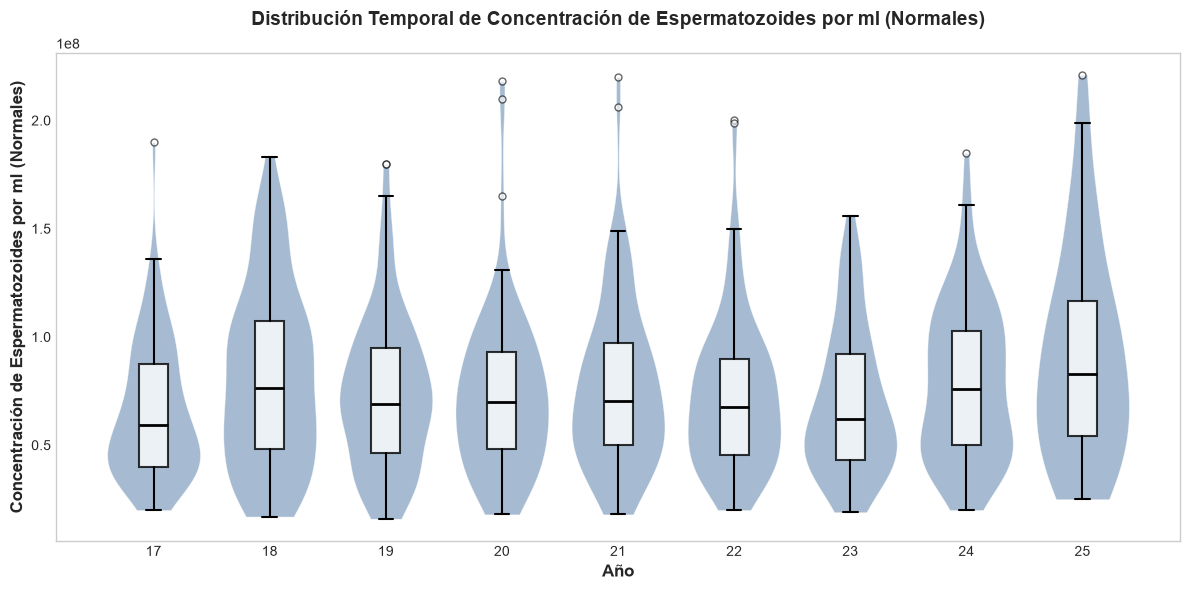


Estadísticos de Concentración de Espermatozoides por ml (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,295,"28,538,728.81","28,336,636.05",0.00,"5,600,000.00","20,000,000.00","41,500,000.00","150,000,000.00","35,900,000.00",99.29,1.32,1.58
18,329,"33,186,504.56","34,411,064.97",0.00,"7,000,000.00","23,000,000.00","49,000,000.00","238,000,000.00","42,000,000.00",103.69,1.79,4.90
19,328,"32,702,743.90","36,106,594.94",0.00,"4,525,000.00","19,000,000.00","53,000,000.00","181,000,000.00","48,475,000.00",110.41,1.41,1.60
20,224,"30,400,446.43","37,439,072.77",0.00,"3,525,000.00","18,000,000.00","42,000,000.00","280,000,000.00","38,475,000.00",123.15,2.58,10.20
21,276,"39,588,405.80","40,205,826.94",0.00,"8,000,000.00","27,000,000.00","53,250,000.00","210,000,000.00","45,250,000.00",101.56,1.32,1.32
22,276,"39,843,840.58","44,816,458.81",0.00,"7,875,000.00","24,000,000.00","57,050,000.00","293,000,000.00","49,175,000.00",112.48,2.11,6.60
23,284,"40,726,760.56","42,704,202.49",0.00,"7,275,000.00","28,000,000.00","63,250,000.00","210,000,000.00","55,975,000.00",104.86,1.51,2.39
24,261,"42,061,111.11","40,416,602.54",0.00,"11,000,000.00","30,000,000.00","62,000,000.00","214,000,000.00","51,000,000.00",96.09,1.44,2.30
25,311,"47,987,459.81","46,401,025.30",0.00,"11,600,000.00","36,000,000.00","71,500,000.00","300,400,000.00","59,900,000.00",96.69,1.48,3.20


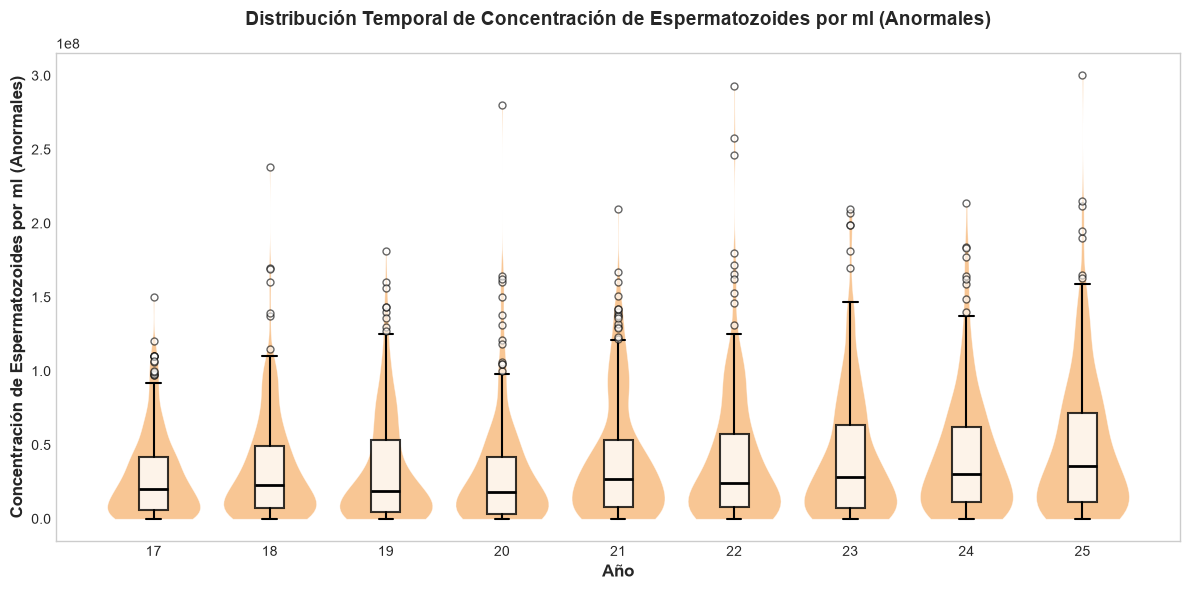

In [15]:
graficas_numericas(pacientes_normales,'concentracion_por_ml', 'Concentración de Espermatozoides por ml (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'concentracion_por_ml', 'Concentración de Espermatozoides por ml (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos de la concentración de espermatozoides por mililitro para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen una concentración 2.0-2.5 veces mayor (66-90 M/ml) que los pacientes Anormales (29-48 M/ml). La variabilidad es mucho menor en el grupo Normal (CV 45.33-53.20%) que en el Anormal (CV 96.09-123.15%). Ambos grupos muestran una tendencia al aumento en los años más recientes, especialmente en 2025.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Ratio Normal/Anormal | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|---------------------|------------------|-------------------|
| 2017 | 65.6 M | 28.5 M | 2.30x | 59.5 M | 20.0 M |
| 2018 | 80.9 M | 33.2 M | 2.44x | 76.5 M | 23.0 M |
| 2019 | 73.8 M | 32.7 M | 2.26x | 69.0 M | 19.0 M |
| 2020 | 72.3 M | 30.4 M | 2.38x | 70.0 M | 18.0 M |
| 2021 | 76.2 M | 39.6 M | 1.92x | 70.5 M | 27.0 M |
| 2022 | 72.7 M | 39.8 M | 1.82x | 67.5 M | 24.0 M |
| 2023 | 69.4 M | 40.7 M | 1.70x | 62.0 M | 28.0 M |
| 2024 | 78.6 M | 42.1 M | 1.87x | 76.0 M | 30.0 M |
| 2025 | 90.4 M | 48.0 M | 1.88x | 83.0 M | 36.0 M |

- El grupo Normal tiene una concentración mucho mayor en todos los años (1.7-2.4x)
- La diferencia es más notable en 2018 (2.44x) y menos en 2023 (1.70x)
- Ambos grupos muestran un aumento en 2025: Normal (+11.8M desde 2024), Anormal (+5.9M desde 2024)
- El rango de medias en Normales es 65.6-90.4 M; en Anormales es 28.5-48.0 M

**Grupo Normal**

| Año | Media (M) | Mediana (M) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 65.6 | 59.5 | Base | Valor más bajo |
| 2018 | 80.9 | 76.5 | +15.3M | Aumento |
| 2019 | 73.8 | 69.0 | -7.1M | Descenso |
| 2020 | 72.3 | 70.0 | -1.5M | Estable |
| 2021 | 76.2 | 70.5 | +3.9M | Leve aumento |
| 2022 | 72.7 | 67.5 | -3.5M | Descenso |
| 2023 | 69.4 | 62.0 | -3.3M | Descenso |
| 2024 | 78.6 | 76.0 | +9.2M | Aumento |
| 2025 | 90.4 | 83.0 | +11.8M | Valor más alto |

- Tendencia general al aumento desde 2017
- Incremento total: +24.8M (38%) entre 2017 y 2025
- 2025 representa el valor más alto de toda la serie

**Grupo Anormal**

| Año | Media (M) | Mediana (M) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 28.5 | 20.0 | Base | Valor más bajo |
| 2018 | 33.2 | 23.0 | +4.7M | Aumento |
| 2019 | 32.7 | 19.0 | -0.5M | Estable |
| 2020 | 30.4 | 18.0 | -2.3M | Descenso |
| 2021 | 39.6 | 27.0 | +9.2M | Aumento |
| 2022 | 39.8 | 24.0 | +0.2M | Estable |
| 2023 | 40.7 | 28.0 | +0.9M | Estable |
| 2024 | 42.1 | 30.0 | +1.4M | Estable |
| 2025 | 48.0 | 36.0 | +5.9M | Valor más alto |

- Tendencia general al aumento desde 2017
- Incremento total: +19.5M (68%) entre 2017 y 2025
- 2025 representa el valor más alto de toda la serie

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 48.0 | 99.3 | Anormal mucho más variable |
| 2018 | 50.8 | 103.7 | Anormal mucho más variable |
| 2019 | 47.4 | 110.4 | Anormal mucho más variable |
| 2020 | 50.4 | 123.2 | Anormal mucho más variable |
| 2021 | 49.5 | 101.6 | Anormal mucho más variable |
| 2022 | 48.1 | 112.5 | Anormal mucho más variable |
| 2023 | 47.8 | 104.9 | Anormal mucho más variable |
| 2024 | 45.3 | 96.1 | Anormal mucho más variable |
| 2025 | 53.2 | 96.7 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (96.09-123.15% vs 45.33-53.20%)
- 2020 muestra la mayor variabilidad en el grupo Anormal (123.15%)
- El grupo Anormal incluye casos con 0 espermatozoides (azoospermia), lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (M) | Anormal Q1 (M) | Normal Q3 (M) | Anormal Q3 (M) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 39.8 | 5.6 | 87.3 | 41.5 |
| 2018 | 48.0 | 7.0 | 107.5 | 49.0 |
| 2019 | 46.5 | 4.5 | 95.0 | 53.0 |
| 2020 | 48.0 | 3.5 | 93.0 | 42.0 |
| 2021 | 50.3 | 8.0 | 97.3 | 53.3 |
| 2022 | 45.3 | 7.9 | 89.8 | 57.1 |
| 2023 | 43.0 | 7.3 | 92.0 | 63.3 |
| 2024 | 50.0 | 11.0 | 102.5 | 62.0 |
| 2025 | 54.0 | 11.6 | 116.5 | 71.5 |

- El 25% de los Normales tiene mayor concentración que el 75% de los Anormales en todos los años
- Superposición mínima entre los grupos
- La separación es más clara en 2025

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Concentración media | 65.6-90.4 M | 28.5-48.0 M | Normal ≈ 2.1x mayor |
| Mediana | 59.5-83.0 M | 18.0-36.0 M | Normal ≈ 2.5x mayor |
| Variabilidad | 45-53% | 96-123% | Normal mucho más homogéneo |
| Tendencia | Aumento (38%) | Aumento (68%) | Ambos grupos mejoran |
| Año máximo | 2025 (90.4M) | 2025 (48.0M) | Ambos en 2025 |
| Sesgo | Positivo leve | Positivo fuerte | Anormal más sesgado |

**Conclusión Final**

La concentración espermática por mililitro es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 2.1 veces (65.6-90.4 M vs 28.5-48.0 M). Ambos grupos muestran una tendencia al aumento a lo largo del tiempo, alcanzando sus valores máximos en 2025 (90.4M en Normales, 48.0M en Anormales). La variabilidad es mucho menor en el grupo Normal (CV 45.33-53.20% vs 96.09-123.15%), lo que indica que los pacientes con buena calidad seminal tienen concentraciones más consistentes. La concentración es uno de los parámetros más efectivos para discriminar entre pacientes Normales y Anormales, junto con el recuento total de espermatozoides por eyaculado.

### **Análisis Comparativo de la Concentración Espermática por ml entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en la concentración de espermatozoides por mililitro entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en la concentración espermática en comparación con aquellos con alguna alteración.

In [16]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'concentracion_por_ml', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 4.29e-05 → No Normal
- Año 18: n = 114, p-value = 2.07e-03 → No Normal
- Año 19: n = 123, p-value = 9.78e-04 → No Normal
- Año 20: n = 85, p-value = 4.52e-06 → No Normal
- Año 21: n = 102, p-value = 4.18e-05 → No Normal
- Año 22: n = 94, p-value = 9.58e-06 → No Normal
- Año 23: n = 81, p-value = 6.70e-04 → No Normal
- Año 24: n = 75, p-value = 1.25e-02 → No Normal
- Año 25: n = 55, p-value = 1.02e-02 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 2.65, p-value = 7.17e-03

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 15.59, p-value = 4.86e-02
- Diferencias Significativas (p < 0.05)

Post-Hoc - Matriz de p-values (Bonferroni)
     17   18   19   20   21   22   23   24   25
17 1.00

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en la concentración espermática entre pacientes Normales y Anormales en todos los años (p < 1e-10). Dentro del grupo Normal, se observan diferencias globales marginalmente significativas entre años (p = 0.049), aunque ninguna comparación post-hoc alcanza significación individual. En el grupo Anormal, se observan diferencias altamente significativas entre años (p < 1e-10), con múltiples comparaciones post-hoc que identifican diferencias entre años iniciales (2017-2020) y años recientes (2024-2025). La prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son extremadamente diferentes (p < 1e-10, KS = 0.50).

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas en ambos grupos
- Las varianzas son significativamente diferentes entre años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Grupo Normal**

- Existe evidencia marginalmente significativa de que la concentración varía entre años (p < 0.05)
- Sin embargo, ninguna comparación post-hoc específica es significativa (todas p > 0.05)
- La significancia global es marginal y probablemente se debe a la tendencia ascendente

**Grupo Anormal**

- Existe evidencia muy sólida de que la concentración varía entre años (p < 0.001)
- El estadístico H = 51.04 indica una diferencia fuerte
- Las comparaciones post-hoc identifican múltiples diferencias significativas

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Conclusión |
|-------------|---------|------------|
| Ninguna | - | No hay comparaciones significativas |

- Aunque la prueba global es significativa (p = 0.049), ningún par específico difiere significativamente
- La significancia global puede deberse a la tendencia acumulativa de los datos
- Posible explicación, el tamaño muestral en algunos años (n=55-123) limita la potencia para detectar diferencias específicas

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2024/2025 | Media otro | Diferencia |
|-------------|---------|-----------------|------------|------------|
| 2017 vs 2024 | 0.006 | 42.1 | 28.5 | +13.6M |
| 2017 vs 2025 | < 0.001 | 48.0 | 28.5 | +19.5M |
| 2018 vs 2025 | 0.005 | 48.0 | 33.2 | +14.8M |
| 2019 vs 2024 | 0.015 | 42.1 | 32.7 | +9.4M |
| 2019 vs 2025 | < 0.001 | 48.0 | 32.7 | +15.3M |
| 2020 vs 2024 | 0.004 | 42.1 | 30.4 | +11.7M |
| 2020 vs 2025 | < 0.001 | 48.0 | 30.4 | +17.6M |

- 2024 y 2025 son los años que difieren de múltiples años anteriores (2017-2020)
- El aumento en el grupo Anormal es significativo desde 2017-2020 hasta 2024-2025
- 2025 muestra el mayor número de diferencias significativas

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 17,692 | < 1e-10 | Significativa | 65.6 vs 28.5 (+37.1M) |
| 2018 | 31,247 | < 1e-10 | Significativa | 80.9 vs 33.2 (+47.7M) |
| 2019 | 32,994 | < 1e-10 | Significativa | 73.8 vs 32.7 (+41.1M) |
| 2020 | 16,069 | < 1e-10 | Significativa | 72.3 vs 30.4 (+41.9M) |
| 2021 | 22,029 | < 1e-10 | Significativa | 76.2 vs 39.6 (+36.6M) |
| 2022 | 20,075 | < 1e-10 | Significativa | 72.7 vs 39.8 (+32.9M) |
| 2023 | 17,254 | < 1e-10 | Significativa | 69.4 vs 40.7 (+28.7M) |
| 2024 | 15,292 | < 1e-10 | Significativa | 78.6 vs 42.1 (+36.5M) |
| 2025 | 13,058 | < 1e-10 | Significativa | 90.4 vs 48.0 (+42.4M) |

- Todos los años muestran diferencias altamente significativas (p < 1e-10)
- 2018 muestra la mayor diferencia absoluta (47.7M)
- 2023 muestra la menor diferencia absoluta (28.7M) pero aún significativa

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son extremadamente diferentes (p < 1e-10)
- El estadístico KS = 0.50 indica una diferencia muy grande entre las distribuciones
- Esto confirma que la concentración es uno de los parámetros más discriminantes entre ambos grupos

**Visualización de las Diferencias por Año**

| Año | Normal (M) | Anormal (M) | Diferencia | Ratio | Significancia |
|-----|------------|-------------|------------|-------|---------------|
| 2017 | 65.6 | 28.5 | 37.1 | 2.30x | ✓ |
| 2018 | 80.9 | 33.2 | 47.7 | 2.44x | ✓ |
| 2019 | 73.8 | 32.7 | 41.1 | 2.26x | ✓ |
| 2020 | 72.3 | 30.4 | 41.9 | 2.38x | ✓ |
| 2021 | 76.2 | 39.6 | 36.6 | 1.92x | ✓ |
| 2022 | 72.7 | 39.8 | 32.9 | 1.83x | ✓ |
| 2023 | 69.4 | 40.7 | 28.7 | 1.70x | ✓ |
| 2024 | 78.6 | 42.1 | 36.5 | 1.87x | ✓ |
| 2025 | 90.4 | 48.0 | 42.4 | 1.88x | ✓ |

**Conclusión Final**

La concentración espermática por mililitro es uno de los parámetros más efectivos para discriminar entre pacientes Normales y Anormales, con diferencias altamente significativas en todos los años (p < 1e-10). Ambos grupos muestran una tendencia al aumento a lo largo del tiempo, alcanzando sus valores máximos en 2025 (90.4M en Normales, 48.0M en Anormales). El grupo Anormal muestra un aumento porcentual mayor (68% vs 38%), lo que podría indicar una mejora en la población general. La diferencia global de distribuciones es extrema (KS = 0.50, p < 1e-10), confirmando que la concentración es un parámetro clave en la evaluación de la calidad seminal.

## **Test de Eosina**

### **Análisis Descriptivo y Visual Comparativo de la Viabilidad Espermática (Test de Eosina) entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del porcentaje de espermatozoides viables evaluado mediante el test de eosina entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en la viabilidad espermática entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Test de Eosina (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,81.65,6.30,64.00,79.00,81.00,87.00,98.00,8.00,7.71,-0.34,0.72
18,114,85.91,9.32,54.00,80.00,88.00,94.00,98.00,14.00,10.84,-0.83,0.38
19,123,84.63,7.29,57.00,80.00,85.00,90.00,98.00,10.00,8.61,-0.54,0.96
20,85,82.75,8.75,55.00,78.00,84.00,90.00,97.00,12.00,10.57,-0.79,0.53
21,102,84.01,7.54,58.00,79.25,84.00,90.00,96.00,10.75,8.98,-0.43,0.21
22,94,82.52,8.35,58.00,79.00,83.00,87.75,98.00,8.75,10.12,-0.81,0.77
23,81,84.33,6.58,66.00,80.00,84.00,89.00,98.00,9.00,7.80,-0.11,-0.32
24,75,82.08,7.14,55.00,78.50,82.00,86.00,96.00,7.50,8.70,-0.69,2.22
25,55,79.05,10.22,54.00,73.50,80.00,86.50,96.00,13.00,12.93,-0.75,0.10


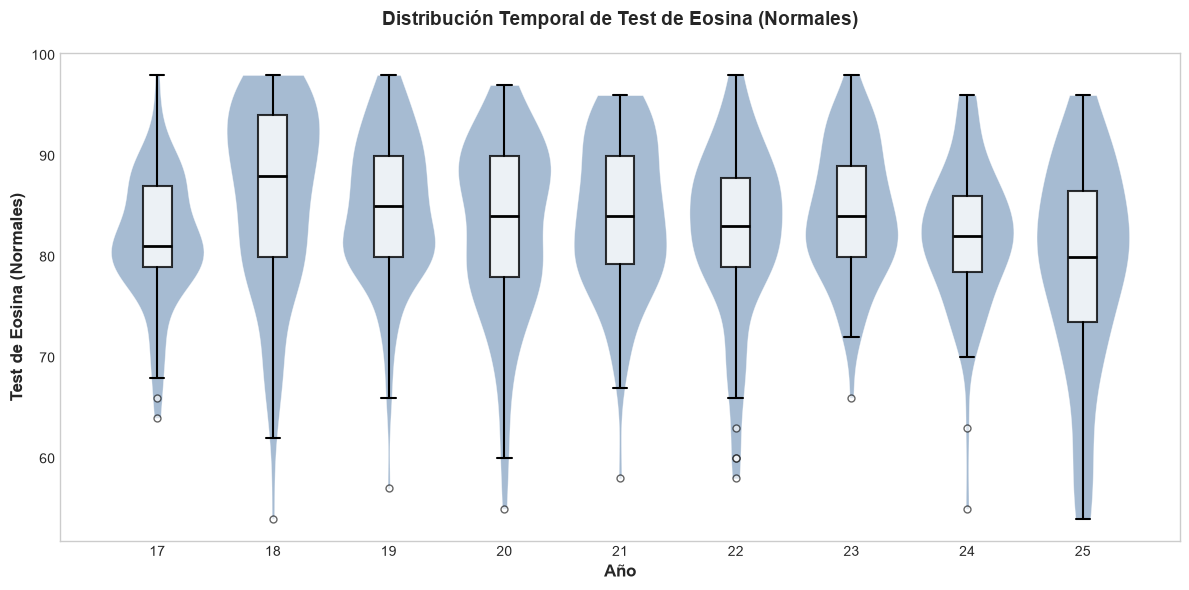


Estadísticos de Test de Eosina (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,284,65.51,22.95,0.00,63.00,71.50,80.00,94.00,17.00,35.04,-1.79,2.59
18,291,67.91,24.34,0.00,61.50,74.00,83.00,98.00,21.50,35.84,-1.51,1.85
19,261,64.06,28.74,0.00,55.00,74.00,83.00,97.00,28.00,44.87,-1.26,0.48
20,172,64.17,27.80,0.00,52.25,74.00,84.25,96.00,32.00,43.32,-1.28,0.62
21,213,64.85,26.20,0.00,58.00,73.00,83.00,96.00,25.00,40.39,-1.25,0.73
22,198,66.99,27.22,0.00,63.25,77.50,84.00,97.00,20.75,40.63,-1.58,1.37
23,188,68.95,25.05,0.00,65.00,78.00,84.00,98.00,19.00,36.32,-1.73,2.16
24,182,66.80,24.70,0.00,56.25,77.00,82.00,96.00,25.75,36.98,-1.53,1.53
25,225,62.17,24.81,0.00,53.00,70.00,80.00,97.00,27.00,39.91,-1.22,0.73


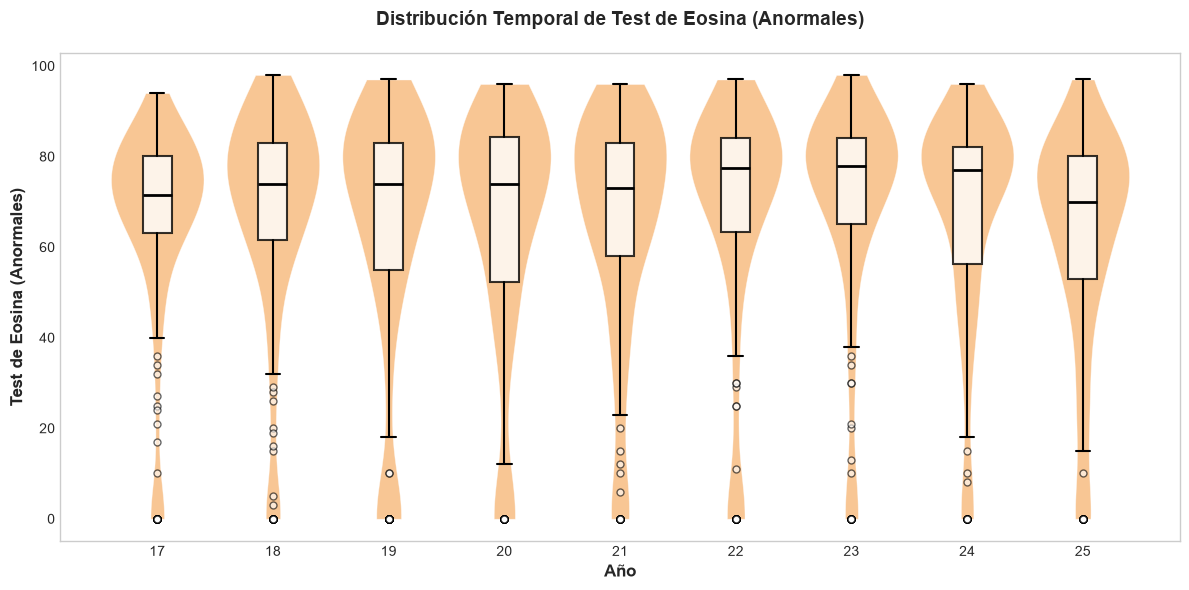

In [17]:
graficas_numericas(pacientes_normales,'test_eosina_pct', 'Test de Eosina (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'test_eosina_pct', 'Test de Eosina (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del porcentaje de espermatozoides viables (test de eosina) para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen una viabilidad mucho mayor (79.05-85.91%) que los pacientes Anormales (62.17-68.95%). La variabilidad es mucho menor en el grupo Normal (CV 7.71-12.93%) que en el Anormal (CV 35.04-44.87%). El grupo Normal presenta distribuciones simétricas o ligeramente sesgadas, mientras que el grupo Anormal muestra un sesgo negativo más pronunciado.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|------------|------------------|-------------------|
| 2017 | 81.7% | 65.5% | +16.2% | 81.0% | 71.5% |
| 2018 | 85.9% | 67.9% | +18.0% | 88.0% | 74.0% |
| 2019 | 84.6% | 64.1% | +20.5% | 85.0% | 74.0% |
| 2020 | 82.8% | 64.2% | +18.6% | 84.0% | 74.0% |
| 2021 | 84.0% | 64.9% | +19.1% | 84.0% | 73.0% |
| 2022 | 82.5% | 67.0% | +15.5% | 83.0% | 77.5% |
| 2023 | 84.3% | 69.0% | +15.3% | 84.0% | 78.0% |
| 2024 | 82.1% | 66.8% | +15.3% | 82.0% | 77.0% |
| 2025 | 79.1% | 62.2% | +16.9% | 80.0% | 70.0% |

- El grupo Normal tiene una viabilidad mucho mayor en todos los años (15.3-20.5 puntos porcentuales)
- La diferencia es más notable en 2019 (20.5%) y menos en 2023 (15.3%)
- Ambos grupos muestran una caída en 2025: Normal (79.05%), Anormal (62.17%)
- La mediana en Normales es 80-88% vs 70-78% en Anormales

**Grupo Normal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 81.7 | 81.0 | Base | Valor bajo |
| 2018 | 85.9 | 88.0 | +4.2% | Pico máximo |
| 2019 | 84.6 | 85.0 | -1.3% | Descenso |
| 2020 | 82.8 | 84.0 | -1.8% | Descenso |
| 2021 | 84.0 | 84.0 | +1.2% | Estable |
| 2022 | 82.5 | 83.0 | -1.5% | Descenso |
| 2023 | 84.3 | 84.0 | +1.8% | Estable |
| 2024 | 82.1 | 82.0 | -2.2% | Descenso |
| 2025 | 79.1 | 80.0 | -3.0% | Valor más bajo |

- Tendencia general estable pero con caída en 2025
- 2018 representa el valor más alto (85.91%)
- 2025 representa el valor más bajo (79.05%)
- El rango es de 6.8 puntos porcentuales

**Grupo Anormal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 65.5 | 71.5 | Base | Estable |
| 2018 | 67.9 | 74.0 | +2.4% | Leve aumento |
| 2019 | 64.1 | 74.0 | -3.8% | Descenso |
| 2020 | 64.2 | 74.0 | +0.1% | Estable |
| 2021 | 64.9 | 73.0 | +0.7% | Estable |
| 2022 | 67.0 | 77.5 | +2.1% | Mejor año |
| 2023 | 69.0 | 78.0 | +2.0% | Mejor año |
| 2024 | 66.8 | 77.0 | -2.2% | Descenso |
| 2025 | 62.2 | 70.0 | -4.6% | Valor más bajo |

- Tendencia con mejora en 2022-2023 seguida de caída en 2025
- 2023 representa el valor más alto (68.95%)
- 2025 representa el valor más bajo (62.17%)
- El rango es de 6.8 puntos porcentuales

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 7.7 | 35.0 | Anormal mucho más variable |
| 2018 | 10.8 | 35.8 | Anormal mucho más variable |
| 2019 | 8.6 | 44.9 | Anormal mucho más variable |
| 2020 | 10.6 | 43.3 | Anormal mucho más variable |
| 2021 | 9.0 | 40.4 | Anormal mucho más variable |
| 2022 | 10.1 | 40.6 | Anormal mucho más variable |
| 2023 | 7.8 | 36.3 | Anormal mucho más variable |
| 2024 | 8.7 | 37.0 | Anormal mucho más variable |
| 2025 | 12.9 | 39.9 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (35.04-44.87% vs 7.71-12.93%)
- 2019 muestra la mayor variabilidad en el grupo Anormal (44.87%)
- El grupo Anormal incluye casos con 0% de viabilidad, lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (%) | Anormal Q1 (%) | Normal Q3 (%) | Anormal Q3 (%) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 79.0 | 63.0 | 87.0 | 80.0 |
| 2018 | 80.0 | 61.5 | 94.0 | 83.0 |
| 2019 | 80.0 | 55.0 | 90.0 | 83.0 |
| 2020 | 78.0 | 52.3 | 90.0 | 84.3 |
| 2021 | 79.3 | 58.0 | 90.0 | 83.0 |
| 2022 | 79.0 | 63.3 | 87.8 | 84.0 |
| 2023 | 80.0 | 65.0 | 89.0 | 84.0 |
| 2024 | 78.5 | 56.3 | 86.0 | 82.0 |
| 2025 | 73.5 | 53.0 | 86.5 | 80.0 |

- El 25% de los Normales tiene mayor viabilidad que el 50% de los Anormales
- El Q1 de Normales (73.50-80%) es similar al Q2 de Anormales (70.00-78.00%)
- Superposición limitada entre los grupos

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Viabilidad media | 79-86% | 62-69% | Normal ≈ 17% mayor |
| Mediana | 80-88% | 70-78% | Normal ≈ 12% mayor |
| Variabilidad | 8-13% | 35-45% | Normal mucho más homogéneo |
| Tendencia | Caída en 2025 | Caída en 2025 | Ambos empeoran |
| Año máximo | 2018 (85.9%) | 2023 (69.0%) | Diferentes años |
| Año mínimo | 2025 (79.1%) | 2025 (62.2%) | Ambos en 2025 |

**Conclusión Final**

La viabilidad espermática es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 17 puntos porcentuales (79.05-85.91% vs 62.17-68.95%). Ambos grupos muestran una caída en 2025, alcanzando sus valores más bajos en ese año. La variabilidad es mucho menor en el grupo Normal (CV 7.71-12.93% vs 35.04-44.87%), indicando que los pacientes con buena calidad seminal tienen viabilidades más consistentes. La viabilidad es un parámetro efectivo para discriminar entre pacientes Normales y Anormales, aunque muestra un patrón diferente al de otros parámetros como la concentración y el recuento total.

### **Análisis Comparativo de la Viabilidad Espermática (Test de Eosina) entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides viables evaluado mediante el test de eosina entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en la viabilidad espermática en comparación con aquellos con alguna alteración.

In [18]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'test_eosina_pct', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 7.05e-02 → Normal
- Año 18: n = 114, p-value = 3.05e-05 → No Normal
- Año 19: n = 123, p-value = 2.78e-03 → No Normal
- Año 20: n = 85, p-value = 2.11e-03 → No Normal
- Año 21: n = 102, p-value = 1.26e-02 → No Normal
- Año 22: n = 94, p-value = 1.09e-03 → No Normal
- Año 23: n = 81, p-value = 4.26e-01 → Normal
- Año 24: n = 75, p-value = 1.04e-02 → No Normal
- Año 25: n = 55, p-value = 1.20e-02 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 3.52, p-value = 5.19e-04

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 34.82, p-value = 2.88e-05
- Diferencias Significativas (p < 0.05)

Post-Hoc - Matriz de p-values (Bonferroni)
     17   18   19   20   21   22   23   24   25
17 1.00 0.00 

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en la viabilidad espermática entre pacientes Normales y Anormales en todos los años (p < 1e-10). Dentro del grupo Normal, se observan diferencias significativas entre años (p = 2.88e-05), con comparaciones post-hoc que identifican diferencias entre varios pares de años (2017 vs 2018, 2018 vs 2024, 2018 vs 2025, 2019 vs 2025). En el grupo Anormal, también se observan diferencias significativas entre años (p = 8.17e-04), con comparaciones post-hoc que identifican diferencias entre años iniciales y 2025 (2017 vs 2023, 2018 vs 2025, 2022 vs 2025, 2023 vs 2025). La prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son significativamente diferentes (p < 1e-10, KS = 0.393).

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- No se cumple el supuesto de homogeneidad de varianzas en ambos grupos
- Las varianzas son significativamente diferentes entre años
- Esto refuerza la necesidad de usar pruebas no paramétricas

**Grupo Normal**

- Existe evidencia muy sólida de que la viabilidad varía entre años (p < 0.001)
- El estadístico H = 34.82 indica una diferencia fuerte

**Grupo Anormal**

- Existe evidencia sólida de que la viabilidad varía entre años (p < 0.001)
- El estadístico H = 26.64 indica una diferencia moderada-fuerte

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media | Diferencia | Interpretación |
|-------------|---------|-------|------------|----------------|
| 2017 vs 2018 | 0.001 | 81.7 vs 85.9 | +4.2% | 2018 mejor que 2017 |
| 2018 vs 2024 | 0.012 | 85.9 vs 82.1 | -3.8% | 2018 mejor que 2024 |
| 2018 vs 2025 | < 0.001 | 85.9 vs 79.1 | -6.8% | 2018 mucho mejor |
| 2019 vs 2025 | 0.026 | 84.6 vs 79.1 | -5.5% | 2019 mejor que 2025 |

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media | Diferencia | Interpretación |
|-------------|---------|-------|------------|----------------|
| 2017 vs 2023 | 0.049 | 65.5 vs 69.0 | +3.5% | 2023 mejor que 2017 |
| 2018 vs 2025 | 0.033 | 67.9 vs 62.2 | -5.7% | 2018 mejor que 2025 |
| 2022 vs 2025 | 0.016 | 67.0 vs 62.2 | -4.8% | 2022 mejor que 2025 |
| 2023 vs 2025 | 0.002 | 69.0 vs 62.2 | -6.8% | 2023 mucho mejor |

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 16,150 | < 1e-10 | Significativa | 81.7 vs 65.5 (+16.2%) |
| 2018 | 25,602 | < 1e-10 | Significativa | 85.9 vs 67.9 (+18.0%) |
| 2019 | 24,304 | < 1e-10 | Significativa | 84.6 vs 64.1 (+20.5%) |
| 2020 | 10,587 | < 1e-10 | Significativa | 82.8 vs 64.2 (+18.6%) |
| 2021 | 16,348 | < 1e-10 | Significativa | 84.0 vs 64.9 (+19.1%) |
| 2022 | 13,065 | < 1e-10 | Significativa | 82.5 vs 67.0 (+15.5%) |
| 2023 | 11,131 | < 1e-10 | Significativa | 84.3 vs 69.0 (+15.3%) |
| 2024 | 9,689 | < 1e-10 | Significativa | 82.1 vs 66.8 (+15.3%) |
| 2025 | 9,065 | < 1e-10 | Significativa | 79.1 vs 62.2 (+16.9%) |

- Todos los años muestran diferencias altamente significativas (p < 1e-10)
- 2019 muestra la mayor diferencia absoluta (20.5%)
- 2023 muestra la menor diferencia absoluta (15.3%)

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son significativamente diferentes (p < 1e-10)
- El estadístico KS = 0.393 indica una diferencia grande entre las distribuciones
- Esto confirma que la viabilidad es un parámetro efectivo para discriminar entre ambos grupos

**Visualización de las Diferencias por Año**

| Año | Normal (%) | Anormal (%) | Diferencia | Significancia |
|-----|------------|-------------|------------|---------------|
| 2017 | 81.7 | 65.5 | 16.2 | ✓ |
| 2018 | 85.9 | 67.9 | 18.0 | ✓ |
| 2019 | 84.6 | 64.1 | 20.5 | ✓ |
| 2020 | 82.8 | 64.2 | 18.6 | ✓ |
| 2021 | 84.0 | 64.9 | 19.1 | ✓ |
| 2022 | 82.5 | 67.0 | 15.5 | ✓ |
| 2023 | 84.3 | 69.0 | 15.3 | ✓ |
| 2024 | 82.1 | 66.8 | 15.3 | ✓ |
| 2025 | 79.1 | 62.2 | 16.9 | ✓ |

**Conclusión Final**

La viabilidad espermática es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 15-20 puntos porcentuales. Ambos grupos muestran diferencias significativas entre años, con patrones distintos: el grupo Normal alcanzó su pico en 2018 (85.91%), mientras que el grupo Anormal lo alcanzó en 2023 (68.95%). Ambos grupos muestran una caída en 2025, alcanzando sus valores más bajos (79.05% en Normales, 62.17% en Anormales). Las distribuciones globales son significativamente diferentes (KS = 0.393, p < 1e-10), confirmando que la viabilidad es un parámetro efectivo para discriminar entre ambos grupos.

## **Motilidad Progresiva**

### **Análisis Descriptivo y Visual Comparativo de la Motilidad Progresiva entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del porcentaje de espermatozoides con motilidad progresiva entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en la motilidad progresiva entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Motilidad Progresiva (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,58.75,9.07,30.00,54.00,60.00,64.00,82.00,10.00,15.44,-0.27,1.07
18,114,52.27,11.23,30.00,44.00,52.50,59.75,84.00,15.75,21.49,0.28,-0.10
19,123,53.57,10.19,31.00,47.00,53.00,60.00,84.00,13.00,19.02,0.29,0.23
20,85,53.05,10.86,30.00,44.00,53.00,62.00,75.00,18.00,20.48,-0.13,-0.97
21,102,52.57,9.73,30.00,45.25,53.50,59.75,82.00,14.50,18.51,0.18,0.14
22,94,52.47,10.08,31.00,45.25,53.00,58.00,75.00,12.75,19.21,-0.02,-0.19
23,81,54.27,8.77,34.00,48.00,55.00,62.00,72.00,14.00,16.16,-0.20,-0.79
24,75,55.72,9.02,33.00,50.00,56.00,61.50,76.00,11.50,16.18,-0.14,-0.32
25,55,58.04,10.54,38.00,51.50,59.00,64.50,82.00,13.00,18.16,0.04,-0.39


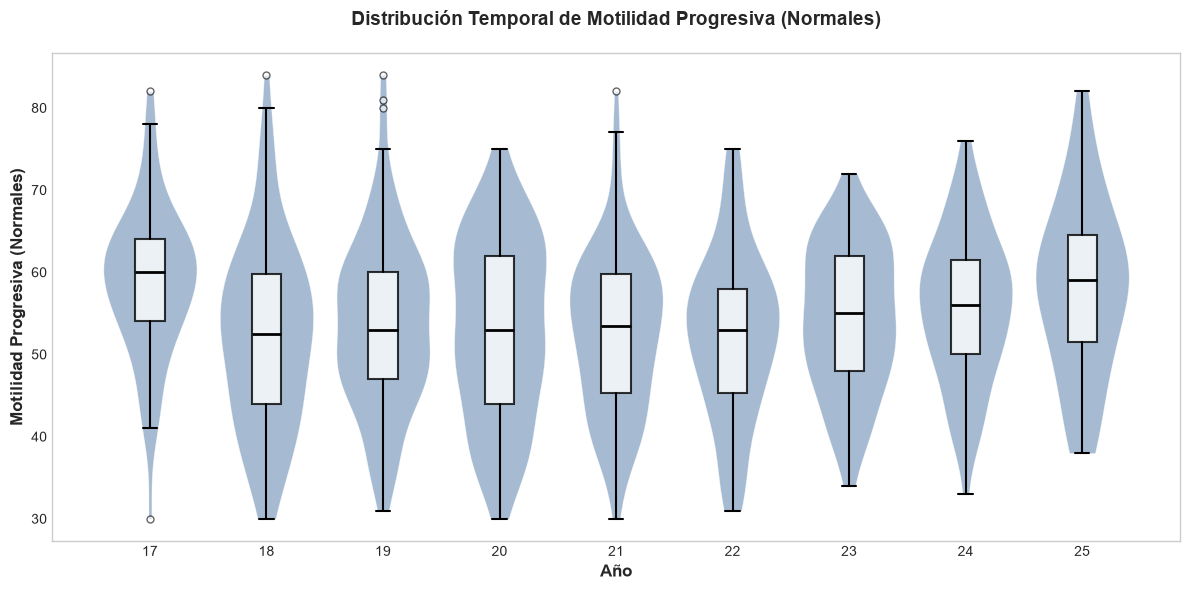


Estadísticos de Motilidad Progresiva (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,294,37.05,21.15,0.00,19.00,42.50,55.00,78.00,36.00,57.09,-0.40,-1.12
18,329,32.12,20.38,0.00,13.00,34.00,49.00,77.00,36.00,63.44,-0.09,-1.08
19,328,33.29,21.20,0.00,13.00,37.00,51.00,80.00,38.00,63.67,-0.15,-1.21
20,225,33.77,20.16,0.00,18.00,36.00,50.00,78.00,32.00,59.68,-0.22,-1.05
21,275,32.81,19.69,0.00,17.00,33.00,50.00,70.00,33.00,60.03,-0.15,-1.16
22,276,35.21,19.98,0.00,19.75,38.00,50.00,84.00,30.25,56.76,-0.29,-0.86
23,284,35.95,20.59,0.00,21.00,38.50,51.00,80.00,30.00,57.27,-0.25,-0.94
24,261,36.13,19.19,0.00,20.00,40.00,50.00,78.00,30.00,53.10,-0.30,-0.86
25,311,37.26,21.03,0.00,22.00,40.00,53.00,84.00,31.00,56.44,-0.17,-0.82


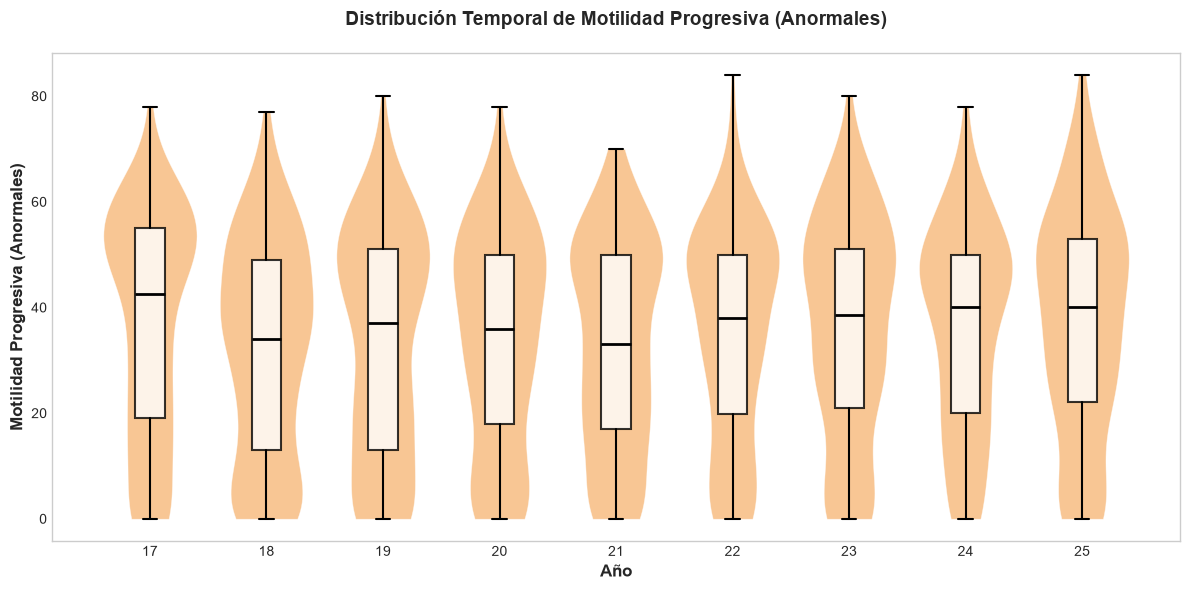

In [19]:
graficas_numericas(pacientes_normales,'motilidad_progresiva_pct', 'Motilidad Progresiva (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'motilidad_progresiva_pct', 'Motilidad Progresiva (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del porcentaje de espermatozoides con motilidad progresiva para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen una motilidad progresiva mucho mayor (52.27-58.75%) que los pacientes Anormales (32.12-37.26%). La variabilidad es mucho menor en el grupo Normal (CV 15.44-21.49%) que en el Anormal (CV 53.10-63.44%). Ambos grupos muestran una tendencia similar, con valores más bajos en los años intermedios y una recuperación en 2025.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|------------|------------------|-------------------|
| 2017 | 58.8% | 37.1% | +21.7% | 60.0% | 42.5% |
| 2018 | 52.3% | 32.1% | +20.2% | 52.5% | 34.0% |
| 2019 | 53.6% | 33.4% | +20.2% | 53.0% | 37.0% |
| 2020 | 53.1% | 33.8% | +19.3% | 53.0% | 36.0% |
| 2021 | 52.6% | 32.8% | +19.8% | 53.5% | 33.0% |
| 2022 | 52.5% | 35.2% | +17.3% | 53.0% | 38.0% |
| 2023 | 54.3% | 36.0% | +18.3% | 55.0% | 38.5% |
| 2024 | 55.7% | 36.1% | +19.6% | 56.0% | 40.0% |
| 2025 | 58.0% | 37.3% | +20.8% | 59.0% | 40.0% |

- El grupo Normal tiene una motilidad mucho mayor en todos los años (17.3-21.7 puntos porcentuales)
- La diferencia es más notable en 2017 (21.7%) y menos en 2022 (17.3%)
- Ambos grupos muestran una recuperación en 2025: Normal (58.04%), Anormal (37.26%)
- La mediana en Normales es 52.50-60% vs 33.00-42.50% en Anormales

**Grupo Normal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 58.8 | 60.0 | Base | Valor más alto |
| 2018 | 52.3 | 52.5 | -6.5% | Caída |
| 2019 | 53.6 | 53.0 | +1.3% | Estable |
| 2020 | 53.1 | 53.0 | -0.5% | Estable |
| 2021 | 52.6 | 53.5 | -0.5% | Valor más bajo |
| 2022 | 52.5 | 53.0 | -0.1% | Estable |
| 2023 | 54.3 | 55.0 | +1.8% | Leve aumento |
| 2024 | 55.7 | 56.0 | +1.4% | Aumento |
| 2025 | 58.0 | 59.0 | +2.3% | Recuperación |

- Tendencia en forma de U: caída hasta 2018, estabilidad, recuperación
- 2017 representa el valor más alto (58.75%)
- 2021-2022 representan los valores más bajos (~52.5%)
- 2025 muestra recuperación a niveles cercanos a 2017

**Grupo Anormal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 37.1 | 42.5 | Base | Estable |
| 2018 | 32.1 | 34.0 | -5.0% | Caída |
| 2019 | 33.4 | 37.0 | +1.3% | Estable |
| 2020 | 33.8 | 36.0 | +0.4% | Estable |
| 2021 | 32.8 | 33.0 | -1.0% | Valor más bajo |
| 2022 | 35.2 | 38.0 | +2.4% | Aumento |
| 2023 | 36.0 | 38.5 | +0.8% | Aumento |
| 2024 | 36.1 | 40.0 | +0.1% | Estable |
| 2025 | 37.3 | 40.0 | +1.2% | Recuperación |

- Tendencia similar al grupo Normal: caída hasta 2021, luego recuperación
- 2021 representa el valor más bajo (32.81%)
- 2025 representa el valor más alto (37.26%)
- El rango es de 4.5 puntos porcentuales

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 15.4 | 57.1 | Anormal mucho más variable |
| 2018 | 21.5 | 63.4 | Anormal mucho más variable |
| 2019 | 19.0 | 63.3 | Anormal mucho más variable |
| 2020 | 20.5 | 59.7 | Anormal mucho más variable |
| 2021 | 18.5 | 60.0 | Anormal mucho más variable |
| 2022 | 19.2 | 56.8 | Anormal mucho más variable |
| 2023 | 16.2 | 57.3 | Anormal mucho más variable |
| 2024 | 16.2 | 53.1 | Anormal mucho más variable |
| 2025 | 18.2 | 56.4 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (53.10-63.44% vs 15.44-21.49%)
- 2018 y 2019 muestran la mayor variabilidad en el grupo Anormal (>63%)
- 2017 muestra la menor variabilidad en el grupo Normal (15.44%)
- El grupo Anormal incluye casos con 0% de motilidad, lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (%) | Anormal Q1 (%) | Normal Q3 (%) | Anormal Q3 (%) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 54.0 | 19.0 | 64.0 | 55.0 |
| 2018 | 44.0 | 13.0 | 59.8 | 49.0 |
| 2019 | 47.0 | 13.5 | 60.0 | 51.0 |
| 2020 | 44.0 | 18.0 | 62.0 | 50.0 |
| 2021 | 45.3 | 17.0 | 59.8 | 50.0 |
| 2022 | 45.3 | 19.8 | 58.0 | 50.0 |
| 2023 | 48.0 | 21.0 | 62.0 | 51.0 |
| 2024 | 50.0 | 20.0 | 61.5 | 50.0 |
| 2025 | 51.5 | 22.0 | 64.5 | 53.0 |

- El 25% de los Normales tiene mayor motilidad que el 50% de los Anormales en algunos años
- Superposición limitada entre los grupos, especialmente en los cuartiles superiores

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Motilidad media | 52-59% | 32-37% | Normal ≈ 20% mayor |
| Mediana | 52-60% | 33-43% | Normal ≈ 17% mayor |
| Variabilidad | 15-21% | 53-63% | Normal mucho más homogéneo |
| Tendencia | Recuperación 2025 | Recuperación 2025 | Ambos mejoran |
| Año máximo | 2017 (58.8%) | 2025 (37.3%) | Diferentes años |
| Año mínimo | 2021-2022 (52.5%) | 2021 (32.8%) | Mismo año |

**Conclusión Final**

La motilidad progresiva es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 20 puntos porcentuales (52.27-58.75% vs 32.12-37.26%). Ambos grupos muestran un patrón similar en forma de U: una caída en 2018, estabilidad en niveles bajos hasta 2022, y una recuperación en 2025. La variabilidad es mucho menor en el grupo Normal (CV 15.44-21.49% vs 53.10-63.44%), indicando que los pacientes con buena calidad seminal tienen motilidades más consistentes. 2025 es un año de recuperación para ambos grupos, alcanzando el grupo Anormal su valor máximo y el grupo Normal acercándose a su nivel de 2017.


### **Análisis Comparativo de la Motilidad Progresiva entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides con motilidad progresiva entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en la motilidad progresiva en comparación con aquellos con alguna alteración.

In [20]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'motilidad_progresiva_pct', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = 3.33e-03 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 2.51e-01 → Normal
- Año 18: n = 114, p-value = 3.36e-01 → Normal
- Año 19: n = 123, p-value = 2.18e-01 → Normal
- Año 20: n = 85, p-value = 5.60e-02 → Normal
- Año 21: n = 102, p-value = 3.36e-01 → Normal
- Año 22: n = 94, p-value = 3.14e-01 → Normal
- Año 23: n = 81, p-value = 1.21e-01 → Normal
- Año 24: n = 75, p-value = 8.40e-01 → Normal
- Año 25: n = 55, p-value = 7.53e-01 → Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.55, p-value = 1.36e-01

Análisis Principal
- Método: ANOVA (paramétrico)
- ANOVA: F = 4.47, p-value = 2.54e-05
Diferencias Significativas (p < 0.05)

POST-HOC (Tukey HSD)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
------------------

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en la motilidad progresiva entre pacientes Normales y Anormales en todos los años (p < 1e-10). Dentro del grupo Normal, se observan diferencias significativas entre años (p = 2.54e-05), con el grupo mostrando normalidad en todos los años, lo que permite usar ANOVA. En el grupo Anormal, también se observan diferencias significativas entre años (p = 0.0080), pero con falta de normalidad en todos los años, lo que requiere pruebas no paramétricas. Las comparaciones por año muestran diferencias altamente significativas en todos los años, y la prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son extremadamente diferentes (p < 1e-10, KS = 0.44).

**Prueba de Normalidad**

- El grupo Normal tiene normalidad en todos los años individuales, pero la prueba global no es normal
- El grupo Anormal no cumple normalidad en ningún año ni globalmente
- Esto justifica el uso de ANOVA en el grupo Normal y Kruskal-Wallis en el Anormal

**Prueba de Homogeneidad de Varianzas**

- Se cumple el supuesto de homogeneidad de varianzas en ambos grupos (p > 0.05)
- Las varianzas son similares entre los años dentro de cada grupo

**Grupo Normal**

- Existe evidencia muy sólida de que la motilidad varía entre años (p < 0.001)
- El estadístico F = 4.47 indica una diferencia significativa
- Tukey HSD identifica múltiples comparaciones significativas

**Grupo Anormal**

- Existe evidencia significativa de que la motilidad varía entre años (p < 0.01)
- El estadístico H = 20.71 indica una diferencia moderada
- Solo una comparación post-hoc es significativa (17 vs 18)

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media | Diferencia | Interpretación |
|-------------|---------|-------|------------|----------------|
| 2017 vs 2018 | < 0.001 | 58.8 vs 52.3 |*-6.5%** | Caída significativa |
| 2017 vs 2019 | 0.016 | 58.8 vs 53.6 | -5.2% | Caída significativa |
| 2017 vs 2020 | 0.012 | 58.8 vs 53.1 | -5.7% | Caída significativa |
| 2017 vs 2021 | 0.002 | 58.8 vs 52.6 | -6.2% | Caída significativa |
| 2017 vs 2022 | 0.002 | 58.8 vs 52.5 | -6.3% | Caída significativa |
| 2018 vs 2025 | 0.015 | 52.3 vs 58.0 | +5.7% | Recuperación |
| 2021 vs 2025 | 0.032 | 52.6 vs 58.0 | +5.4% | Recuperación |
| 2022 vs 2025 | 0.031 | 52.5 vs 58.0 | +5.5% | Recuperación |

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media | Diferencia | Interpretación |
|-------------|---------|-------|------------|----------------|
| 2017 vs 2018 | 0.030 | 37.1 vs 32.1 | -5.0% | Caída significativa |

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 17,378 | < 1e-10 | Significativa | 58.8 vs 37.1 (+21.7%) |
| 2018 | 29,565 | < 1e-10 | Significativa | 52.3 vs 32.1 (+20.2%) |
| 2019 | 31,213 | < 1e-10 | Significativa | 53.6 vs 33.4 (+20.2%) |
| 2020 | 14,972 | < 1e-10 | Significativa | 53.1 vs 33.8 (+19.3%) |
| 2021 | 22,191 | < 1e-10 | Significativa | 52.6 vs 32.8 (+19.8%) |
| 2022 | 19,820 | < 1e-10 | Significativa | 52.5 vs 35.2 (+17.3%) |
| 2023 | 17,761 | < 1e-10 | Significativa | 54.3 vs 36.0 (+18.3%) |
| 2024 | 15,968 | < 1e-10 | Significativa | 55.7 vs 36.1 (+19.6%) |
| 2025 | 13,699 | < 1e-10 | Significativa | 58.0 vs 37.3 (+20.8%) |

- Todos los años muestran diferencias altamente significativas (p < 1e-10)
- 2017 muestra la mayor diferencia absoluta (21.7%)
- 2022 muestra la menor diferencia absoluta (17.3%)

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son extremadamente diferentes (p < 1e-10)
- El estadístico KS = 0.44 indica una diferencia muy grande entre las distribuciones
- Esto confirma que la motilidad progresiva es uno de los parámetros más discriminantes

**Visualización de las Diferencias por Año**

| Año | Normal (%) | Anormal (%) | Diferencia | Significancia |
|-----|------------|-------------|------------|---------------|
| 2017 | 58.8 | 37.1 | 21.7 | ✓ |
| 2018 | 52.3 | 32.1 | 20.2 | ✓ |
| 2019 | 53.6 | 33.4 | 20.2 | ✓ |
| 2020 | 53.1 | 33.8 | 19.3 | ✓ |
| 2021 | 52.6 | 32.8 | 19.8 | ✓ |
| 2022 | 52.5 | 35.2 | 17.3 | ✓ |
| 2023 | 54.3 | 36.0 | 18.3 | ✓ |
| 2024 | 55.7 | 36.1 | 19.6 | ✓ |
| 2025 | 58.0 | 37.3 | 20.8 | ✓ |

**Conclusión Final**

La motilidad progresiva es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 18-22 puntos porcentuales (52.27-58.75% vs 32.12-37.26%). Ambos grupos muestran un patrón en forma de U: una caída en 2018, estabilidad en niveles bajos hasta 2022, y una recuperación en 2025. El grupo Normal es el único que cumple normalidad en todos los años, lo que permite el uso de métodos paramétricos. Las distribuciones globales son extremadamente diferentes (KS = 0.44, p < 1e-10), confirmando que la motilidad progresiva es uno de los parámetros más discriminantes entre ambos grupos.

## **Motilidad Total**

### **Análisis Descriptivo y Visual Comparativo de la Motilidad Total entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del porcentaje de motilidad total (progresiva + no progresiva) entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en la motilidad total entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Motilidad Total (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,73.14,10.76,45.00,68.50,76.00,80.00,90.00,11.50,14.72,-1.15,0.66
18,114,68.40,10.56,42.00,63.00,69.00,76.00,89.00,13.00,15.44,-0.49,-0.05
19,123,69.40,9.42,43.00,64.00,71.00,77.00,86.00,13.00,13.58,-0.50,-0.14
20,85,67.16,11.95,42.00,57.00,69.00,77.00,86.00,20.00,17.80,-0.45,-0.69
21,102,66.73,10.75,44.00,60.25,69.00,75.00,90.00,14.75,16.10,-0.59,-0.31
22,94,66.41,9.81,43.00,61.00,68.50,73.75,85.00,12.75,14.77,-0.57,-0.24
23,81,67.60,8.77,44.00,63.00,69.00,74.00,82.00,11.00,12.98,-0.67,-0.10
24,75,66.92,9.52,43.00,61.50,69.00,74.00,84.00,12.50,14.22,-0.53,-0.38
25,55,65.98,9.92,46.00,62.00,67.00,73.50,85.00,11.50,15.03,-0.36,-0.47


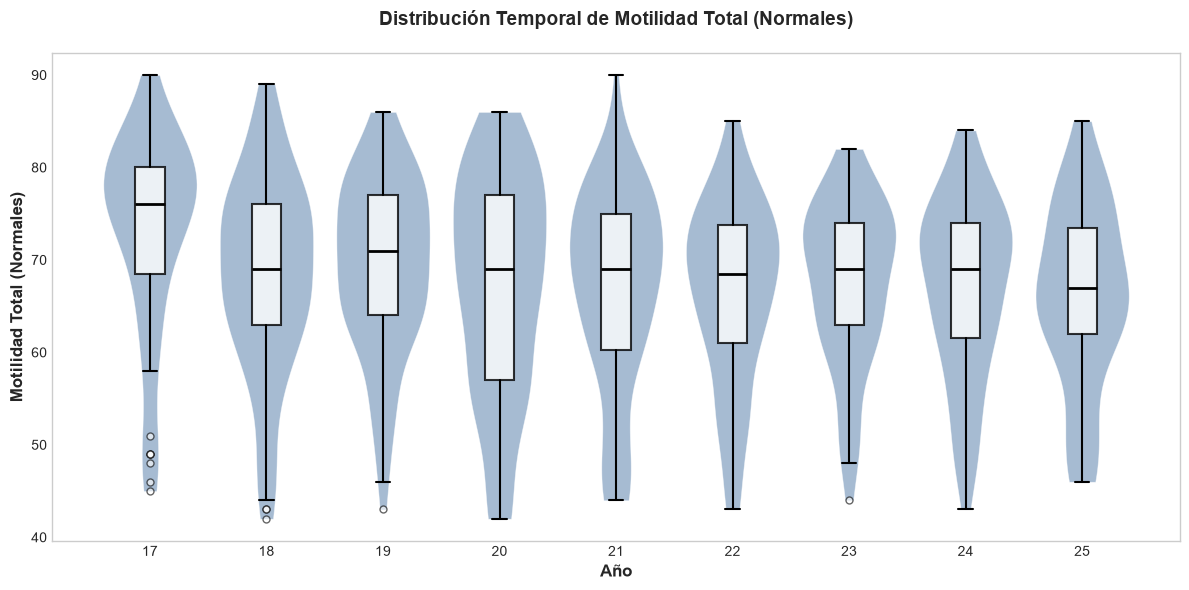


Estadísticos de Motilidad Total (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,294,49.70,26.46,0.00,28.25,57.00,73.00,85.00,44.75,53.23,-0.52,-1.01
18,329,44.06,25.40,0.00,23.00,45.00,66.00,89.00,43.00,57.64,-0.19,-1.08
19,328,45.30,26.48,0.00,22.00,52.00,68.25,85.00,46.25,58.45,-0.37,-1.22
20,225,46.92,25.73,0.00,26.00,53.00,69.00,89.00,43.00,54.83,-0.45,-1.04
21,275,43.66,24.86,0.00,23.50,44.00,67.00,88.00,43.50,56.93,-0.19,-1.14
22,276,45.97,24.46,0.00,26.75,51.50,66.25,86.00,39.50,53.20,-0.47,-0.96
23,284,47.52,25.21,0.00,28.75,53.00,69.00,90.00,40.25,53.05,-0.50,-0.92
24,261,46.84,24.23,0.00,28.00,49.00,67.00,88.00,39.00,51.73,-0.30,-0.97
25,311,45.13,23.05,0.00,30.00,48.00,64.00,91.00,34.00,51.08,-0.34,-0.74


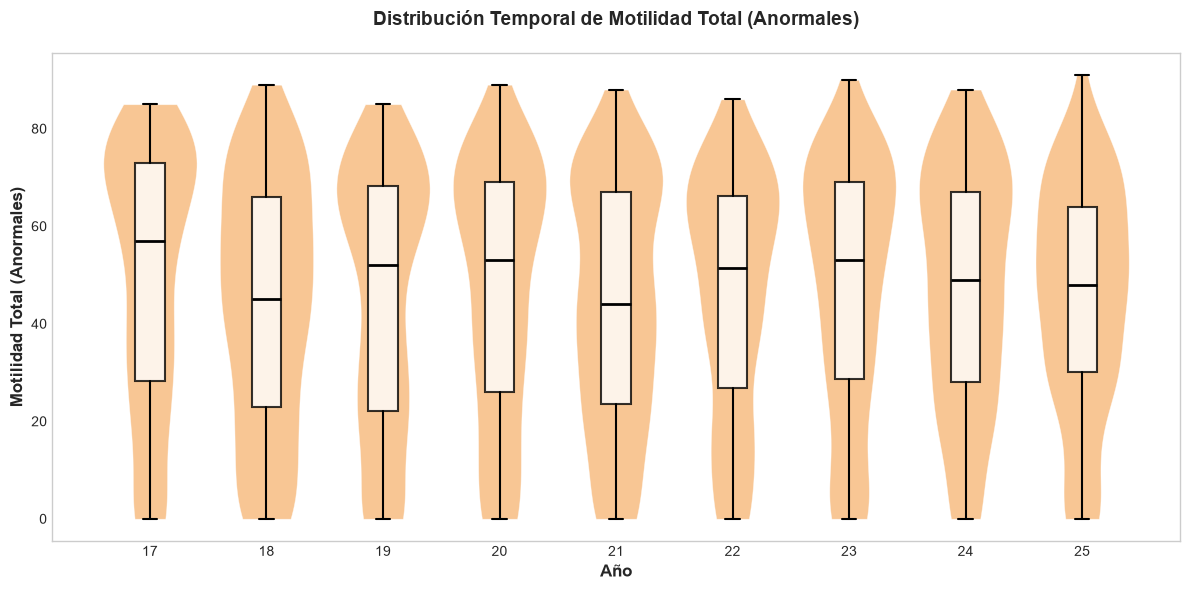

In [21]:
graficas_numericas(pacientes_normales,'motilidad_total_pct', 'Motilidad Total (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'motilidad_total_pct', 'Motilidad Total (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del porcentaje de motilidad total (progresiva + no progresiva) para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen una motilidad total mucho mayor (65.98-73.14%) que los pacientes Anormales (43.66-49.70%). La variabilidad es mucho menor en el grupo Normal (CV 12.98-17.80%) que en el Anormal (CV 51.08-58.45%). El grupo Normal presenta distribuciones relativamente simétricas, mientras que el grupo Anormal muestra mayor dispersión.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|------------|------------------|-------------------|
| 2017 | 73.1% | 49.7% | +23.4% | 76.0% | 57.0% |
| 2018 | 68.4% | 44.1% | +24.3% | 69.0% | 45.0% |
| 2019 | 69.4% | 45.3% | +24.1% | 71.0% | 52.0% |
| 2020 | 67.2% | 46.9% | +20.2% | 69.0% | 53.0% |
| 2021 | 66.7% | 43.7% | +23.1% | 69.0% | 44.0% |
| 2022 | 66.4% | 46.0% | +20.4% | 68.5% | 51.5% |
| 2023 | 67.6% | 47.5% | +20.1% | 69.0% | 53.0% |
| 2024 | 66.9% | 46.8% | +20.1% | 69.0% | 49.0% |
| 2025 | 66.0% | 45.1% | +20.9% | 67.0% | 48.0% |

- El grupo Normal tiene una motilidad total mucho mayor en todos los años (20.1-24.3 puntos porcentuales)
- La diferencia es más notable en 2018 (24.3%) y menos en 2023 (20.1%)
- Ambos grupos muestran una tendencia descendente hacia 2025
- La mediana en Normales es 67-76% vs 44-57% en Anormales

**Grupo Normal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 73.1 | 76.0 | Base | Valor más alto |
| 2018 | 68.4 | 69.0 | -4.7% | Caída |
| 2019 | 69.4 | 71.0 | +1.0% | Estable |
| 2020 | 67.2 | 69.0 | -2.2% | Descenso |
| 2021 | 66.7 | 69.0 | -0.5% | Descenso |
| 2022 | 66.4 | 68.5 | -0.3% | Valor más bajo |
| 2023 | 67.6 | 69.0 | +1.2% | Leve aumento |
| 2024 | 66.9 | 69.0 | -0.7% | Estable |
| 2025 | 66.0 | 67.0 | -0.9% | Descenso |

- Tendencia descendente desde 2017
- 2017 representa el valor más alto (73.14%)
- 2025 representa el valor más bajo (65.98%)
- Caída total de 7.1 puntos porcentuales entre 2017 y 2025

**Grupo Anormal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 49.7 | 57.0 | Base | Valor más alto |
| 2018 | 44.1 | 45.0 | -5.6% | Caída |
| 2019 | 45.3 | 52.0 | +1.2% | Estable |
| 2020 | 46.9 | 53.0 | +1.6% | Estable |
| 2021 | 43.7 | 44.0 | -3.2% | Valor más bajo |
| 2022 | 46.0 | 51.5 | +2.3% | Aumento |
| 2023 | 47.5 | 53.0 | +1.5% | Aumento |
| 2024 | 46.8 | 49.0 | -0.7% | Estable |
| 2025 | 45.1 | 48.0 | -1.7% | Descenso |

- Tendencia descendente con fluctuaciones
- 2017 representa el valor más alto (49.70%)
- 2021 representa el valor más bajo (43.66%)
- Caída total de 4.6 puntos porcentuales entre 2017 y 2025

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 14.7 | 53.2 | Anormal mucho más variable |
| 2018 | 15.4 | 57.6 | Anormal mucho más variable |
| 2019 | 13.6 | 58.5 | Anormal mucho más variable |
| 2020 | 17.8 | 54.8 | Anormal mucho más variable |
| 2021 | 16.1 | 56.9 | Anormal mucho más variable |
| 2022 | 14.8 | 53.2 | Anormal mucho más variable |
| 2023 | 13.0 | 53.1 | Anormal mucho más variable |
| 2024 | 14.2 | 51.7 | Anormal mucho más variable |
| 2025 | 15.0 | 51.1 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (51.08-58.45% vs 12.98-17.80%)
- 2019 muestra la mayor variabilidad en el grupo Anormal (58.45%)
- 2023 muestra la menor variabilidad en el grupo Normal (12.98%)
- El grupo Anormal incluye casos con 0% de motilidad, lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (%) | Anormal Q1 (%) | Normal Q3 (%) | Anormal Q3 (%) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 68.5 | 28.3 | 80.0 | 73.0 |
| 2018 | 63.0 | 23.0 | 76.0 | 66.0 |
| 2019 | 64.0 | 22.0 | 77.0 | 68.3 |
| 2020 | 57.0 | 26.0 | 77.0 | 69.0 |
| 2021 | 60.3 | 23.5 | 75.0 | 67.0 |
| 2022 | 61.0 | 26.8 | 73.8 | 66.3 |
| 2023 | 63.0 | 28.8 | 74.0 | 69.0 |
| 2024 | 61.5 | 28.0 | 74.0 | 67.0 |
| 2025 | 62.0 | 30.0 | 73.5 | 64.0 |

- El 25% de los Normales tiene mayor motilidad que el 75% de los Anormales en algunos años
- Superposición moderada entre los grupos

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Motilidad media | 66-73% | 44-50% | Normal ≈ 23% mayor |
| Mediana | 67-76% | 44-57% | Normal ≈ 19% mayor |
| Variabilidad | 13-18% | 51-58% | Normal mucho más homogéneo |
| Tendencia | Descenso | Descenso | Ambos empeoran |
| Año máximo | 2017 (73.1%) | 2017 (49.7%) | Mismo año |
| Año mínimo | 2025 (66.0%) | 2021 (43.7%) | Diferentes años |

**Conclusión Final**

La motilidad total es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 20-24 puntos porcentuales (65.98-73.14% vs 43.66-49.70%). Ambos grupos muestran una tendencia descendente desde 2017, alcanzando sus valores más bajos en 2021-2025. El grupo Normal es mucho más homogéneo (CV 12.98-17.80% vs 51.08-58.45% en el grupo Anormal). La motilidad total es un parámetro efectivo para discriminar entre pacientes Normales y Anormales, aunque muestra una tendencia descendente que merece ser investigada.

### **Análisis Comparativo de la Motilidad Total entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el porcentaje de motilidad total (progresiva + no progresiva) entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en la motilidad total en comparación con aquellos con alguna alteración.

In [22]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'motilidad_total_pct', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 6.45e-06 → No Normal
- Año 18: n = 114, p-value = 2.21e-02 → No Normal
- Año 19: n = 123, p-value = 1.69e-02 → No Normal
- Año 20: n = 85, p-value = 3.14e-03 → No Normal
- Año 21: n = 102, p-value = 3.74e-04 → No Normal
- Año 22: n = 94, p-value = 7.26e-03 → No Normal
- Año 23: n = 81, p-value = 5.68e-03 → No Normal
- Año 24: n = 75, p-value = 2.06e-02 → No Normal
- Año 25: n = 55, p-value = 8.43e-02 → Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 1.32, p-value = 2.30e-01

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 33.60, p-value = 4.81e-05
- Diferencias Significativas (p < 0.05)

Post-Hoc - Matriz de p-values (Bonferroni)
     17   18   19   20   21   22   23   24   25
17 1.00 0.

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en la motilidad total entre pacientes Normales y Anormales en todos los años (p < 1e-10 en la mayoría). Dentro del grupo Normal, se observan diferencias altamente significativas entre años (p = 4.81e-05), con el año 2017 siendo el que difiere de todos los años posteriores. En el grupo Anormal, también se observan diferencias significativas entre años (p = 0.0297), con una comparación post-hoc significativa (2017 vs 2021). Las comparaciones por año muestran diferencias altamente significativas en todos los años, y la prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son extremadamente diferentes (p < 1e-10, KS = 0.43).

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- El grupo Normal cumple el supuesto de homogeneidad de varianzas (p > 0.05)
- El grupo Anormal no cumple (p < 0.05), lo que refuerza el uso de Kruskal-Wallis

**Grupo Normal**

- Existe evidencia muy sólida de que la motilidad total varía entre años (p < 0.001)
- El estadístico H = 33.60 indica una diferencia fuerte
- 2017 difiere de todos los años posteriores (7 comparaciones significativas de 8)

**Grupo Anormal**

- Existe evidencia significativa de que la motilidad total varía entre años (p < 0.05)
- El estadístico H = 17.04 indica una diferencia moderada
- Solo una comparación post-hoc es significativa (2017 vs 2021)

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2017 | Media otro | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2018 | 0.010 | 73.1 | 68.4 | -4.7% |
| 2017 vs 2020 | 0.005 | 73.1 | 67.2 | -5.9% |
| 2017 vs 2021 | < 0.001 | 73.1 | 66.7 | -6.4% |
| 2017 vs 2022 | < 0.001 | 73.1 | 66.4 | -6.7% |
| 2017 vs 2023 | 0.002 | 73.1 | 67.6 | -5.5% |
| 2017 vs 2024 | < 0.001 | 73.1 | 66.9 | -6.2% |
| 2017 vs 2025 | < 0.001 | 73.1 | 66.0 | -7.1% |

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2017 | Media 2021 | Diferencia |
|-------------|---------|------------|------------|------------|
| 2017 vs 2021 | 0.039 | 49.7 | 43.7 | -6.0% |

- El grupo Normal muestra un patrón claro, 2017 es significativamente mayor que todos los años posteriores
- El grupo Anormal muestra solo una diferencia significativa (2017 vs 2021)
- La magnitud de la caída en el grupo Normal es de 4.7-7.1 puntos porcentuales

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 16,542 | < 1e-10** | Significativa** | 73.1 vs 49.7 (+23.4%) |
| 2018 | 29,504 | < 1e-10 | Significativa | 68.4 vs 44.1 (+24.3%) |
| 2019 | 31,160 | < 1e-10 | Significativa | 69.4 vs 45.3 (+24.1%) |
| 2020 | 14,021 | 2.39e-10 | Significativa | 67.2 vs 46.9 (+20.3%) |
| 2021 | 21,633 | < 1e-10 | Significativa | 66.7 vs 43.7 (+23.0%) |
| 2022 | 19,605 | < 1e-10 | Significativa | 66.4 vs 46.0 (+20.4%) |
| 2023 | 16,974 | < 1e-10 | Significativa | 67.6 vs 47.5 (+20.1%) |
| 2024 | 14,559 | 1.23e-10 | Significativa | 66.9 vs 46.8 (+20.1%) |
| 2025 | 13,294 | < 1e-10 | Significativa | 66.0 vs 45.1 (+20.9%) |

- Todos los años muestran diferencias altamente significativas (p < 1e-10 o < 1e-9)
- 2018 muestra la mayor diferencia absoluta (24.3%)
- 2023 muestra la menor diferencia absoluta (20.1%)

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son extremadamente diferentes (p < 1e-10)
- El estadístico KS = 0.43 indica una diferencia muy grande entre las distribuciones
- Esto confirma que la motilidad total es uno de los parámetros más discriminantes

**Visualización de las Diferencias por Año**

| Año | Normal (%) | Anormal (%) | Diferencia | Significancia |
|-----|------------|-------------|------------|---------------|
| 2017 | 73.1 | 49.7 | 23.4 | ✓ |
| 2018 | 68.4 | 44.1 | 24.3 | ✓ |
| 2019 | 69.4 | 45.3 | 24.1 | ✓ |
| 2020 | 67.2 | 46.9 | 20.3 | ✓ |
| 2021 | 66.7 | 43.7 | 23.0 | ✓ |
| 2022 | 66.4 | 46.0 | 20.4 | ✓ |
| 2023 | 67.6 | 47.5 | 20.1 | ✓ |
| 2024 | 66.9 | 46.8 | 20.1 | ✓ |
| 2025 | 66.0 | 45.1 | 20.9 | ✓ |

**Conclusión Final**

La motilidad total es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 20-24 puntos porcentuales (65.98-73.14% vs 43.66-49.70%). El grupo Normal muestra una caída sostenida desde 2017, con 2017 difiriendo significativamente de todos los años posteriores. El grupo Anormal también muestra una caída, pero menos pronunciada. Las distribuciones globales son extremadamente diferentes (KS = 0.43, p < 1e-10), confirmando que la motilidad total es uno de los parámetros más discriminantes entre ambos grupos.

## **Espermatozoides Normales**

### **Análisis Descriptivo y Visual Comparativo del Porcentaje de Espermatozoides Normales entre Pacientes Normales y Anormales**

Para caracterizar y comparar la distribución del porcentaje de espermatozoides con morfología normal entre los dos grupos de pacientes clasificados según los criterios de normalidad de la OMS, se generan análisis descriptivos y representaciones gráficas independientes para cada grupo. Los violinplots con boxplots superpuestos permiten visualizar la forma de la distribución, la densidad de los datos, la posición de la mediana y la presencia de valores atípicos en cada grupo. Esta comparación facilita la identificación de diferencias en la morfología espermática entre pacientes con parámetros normales y aquellos con alguna alteración, así como la comprensión de cómo este parámetro contribuye a la clasificación global de los pacientes.

Estadísticos de Espermatozoides Normales (Normales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,72,5.50,2.14,4.00,4.00,5.00,6.00,12.00,2.00,38.84,1.86,2.81
18,114,6.17,2.52,4.00,4.00,5.00,7.00,16.00,3.00,40.81,1.42,1.79
19,123,5.89,2.01,4.00,4.00,5.00,7.00,15.00,3.00,34.06,1.45,2.98
20,85,6.27,2.58,4.00,5.00,6.00,7.00,19.00,2.00,41.13,2.26,7.13
21,102,5.50,1.66,4.00,4.00,5.00,6.00,13.00,2.00,30.14,1.69,4.24
22,94,9.06,16.85,4.00,4.00,5.00,7.00,98.00,3.00,185.89,4.83,22.66
23,81,5.57,1.79,4.00,4.00,5.00,6.00,12.00,2.00,32.12,1.58,2.81
24,75,5.68,1.47,4.00,4.00,5.00,7.00,9.00,3.00,25.91,0.52,-0.78
25,55,5.29,1.52,4.00,4.00,5.00,6.00,10.00,2.00,28.80,1.08,0.38


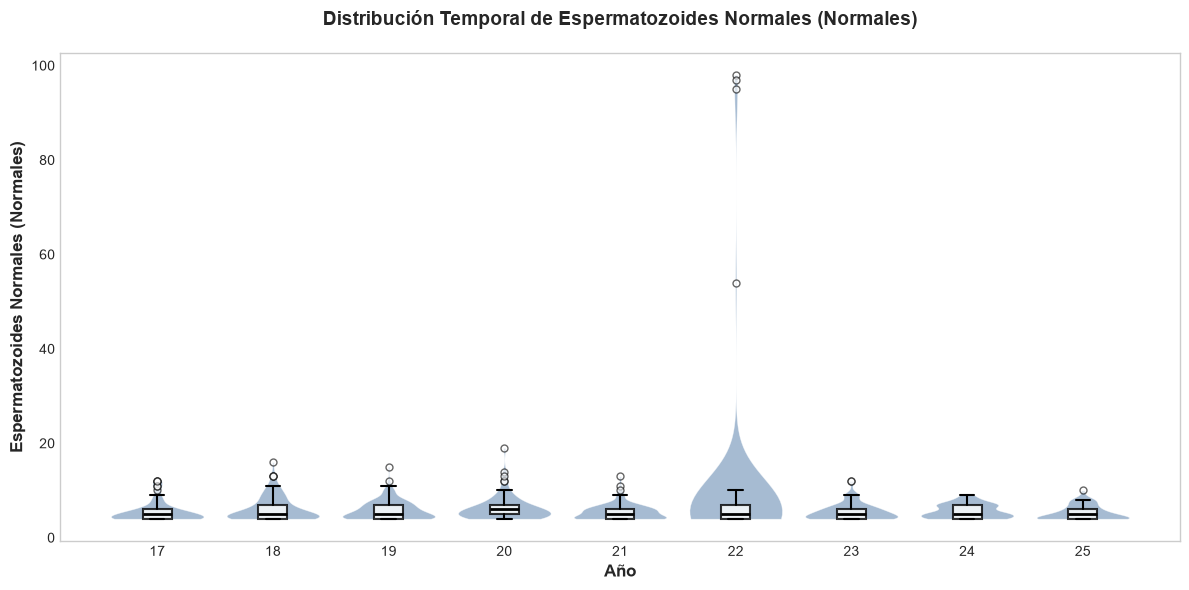


Estadísticos de Espermatozoides Normales (Anormales) según Año de Estudio


,Count,Mean,Std,Min,Q1,Q2,Q3,Max,IQR,CV,Skew,Kurtosis
año,,,,,,,,,,,,
17,284,1.67,1.49,0.00,1.00,2.00,2.00,11.00,1.00,89.24,2.28,10.26
18,285,1.84,1.96,0.00,1.00,2.00,2.00,20.00,1.00,106.68,3.82,27.75
19,259,1.58,1.55,0.00,0.00,1.00,2.00,8.00,2.00,97.94,1.36,2.30
20,172,1.50,1.57,0.00,1.00,1.00,2.00,11.00,1.00,104.36,2.74,12.31
21,203,1.77,1.53,0.00,1.00,2.00,2.00,10.00,1.00,86.26,1.50,4.20
22,194,1.78,1.66,0.00,1.00,2.00,2.00,10.00,1.00,93.34,1.61,4.07
23,182,2.51,7.21,0.00,1.00,2.00,2.00,96.00,1.00,287.83,12.20,158.32
24,181,2.01,1.64,0.00,1.00,2.00,2.00,10.00,1.00,81.54,1.83,5.10
25,221,1.70,1.30,0.00,1.00,1.00,2.00,10.00,1.00,76.70,1.95,8.41


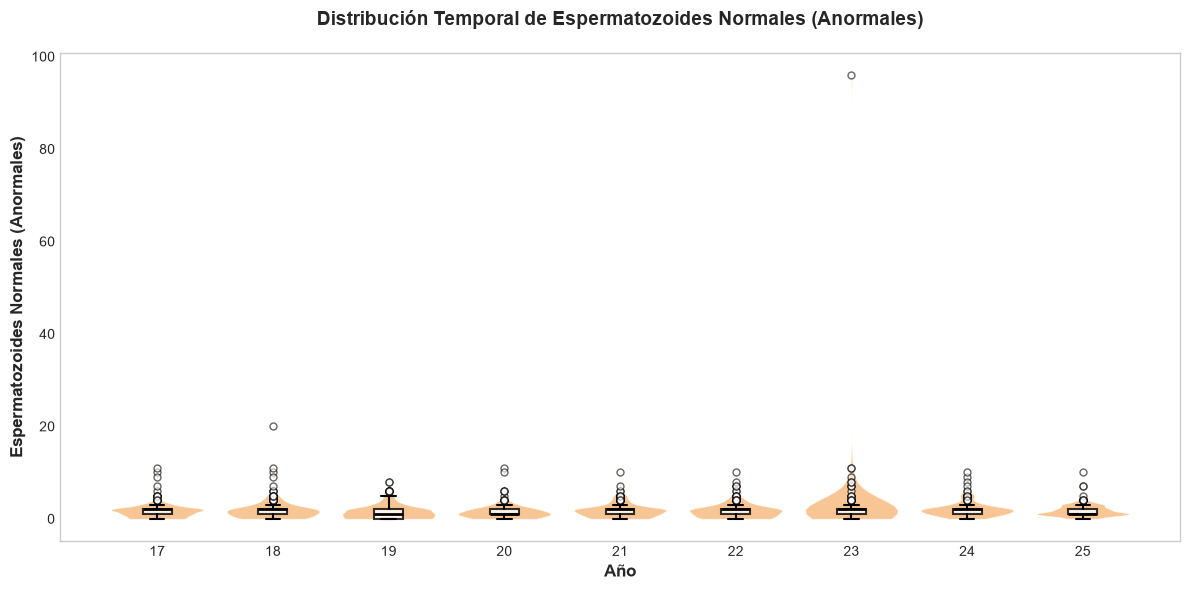

In [23]:
graficas_numericas(pacientes_normales,'espermatozoides_normales_pct', 'Espermatozoides Normales (Normales)', color='#4E79A7')

graficas_numericas(pacientes_anormales,'espermatozoides_normales_pct', 'Espermatozoides Normales (Anormales)', color='#F28E2B')

**Resumen General**

Las tablas muestran los estadísticos descriptivos del porcentaje de espermatozoides con morfología normal para pacientes clasificados como Normales y Anormales según los criterios de la OMS. Se observa una diferencia muy marcada entre ambos grupos: los pacientes Normales tienen un porcentaje de formas normales mucho mayor (5.29-9.06%) que los pacientes Anormales (1.50-2.51%). La variabilidad es mucho mayor en el grupo Anormal (CV 76.70-287.83%) que en el Normal (CV 25.91-185.89%), con outliers extremos en 2022 y 2023 (98% y 96%) que distorsionan las medias en ambos grupos.

**Análisis Comparativo de Medidas de Tendencia Central**

| Año | Normal (Media) | Anormal (Media) | Diferencia | Normal (Mediana) | Anormal (Mediana) |
|-----|---------------|-----------------|------------|------------------|-------------------|
| 2017 | 5.5% | 1.7% | +3.8% | 5.0% | 2.0% |
| 2018 | 6.2% | 1.8% | +4.3% | 5.0% | 2.0% |
| 2019 | 5.9% | 1.6% | +4.3% | 5.0% | 1.0% |
| 2020 | 6.3% | 1.5% | +4.8% | 6.0% | 1.0% |
| 2021 | 5.5% | 1.8% | +3.7% | 5.0% | 2.0% |
| 2022 | 9.1% | 1.8% | +7.3% | 5.0% | 2.0% |
| 2023 | 5.6% | 2.5% | +3.1% | 5.0% | 2.0% |
| 2024 | 5.7% | 2.0% | +3.7% | 5.0% | 2.0% |
| 2025 | 5.3% | 1.7% | +3.6% | 5.0% | 1.0% |

- El grupo Normal tiene un porcentaje de formas normales mucho mayor en todos los años
- La diferencia es más notable en 2022 (7.3%) debido al outlier en el grupo Normal (98%)
- La mediana en Normales es 5-6% vs 1-2% en Anormales
- El grupo Normal supera el umbral de normalidad (4%), mientras que el Anormal está muy por debajo

**Grupo Normal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 5.5 | 5.0 | Base | Límite normal |
| 2018 | 6.2 | 5.0 | +0.7% | Estable |
| 2019 | 5.9 | 5.0 | -0.3% | Estable |
| 2020 | 6.3 | 6.0 | +0.4% | Mejor año |
| 2021 | 5.5 | 5.0 | -0.8% | Descenso |
| 2022 | 9.1 | 5.0 | +3.6% | Outlier (98%) |
| 2023 | 5.6 | 5.0 | -3.5% | Descenso |
| 2024 | 5.7 | 5.0 | +0.1% | Estable |
| 2025 | 5.3 | 5.0 | -0.4% | Valor más bajo |

- La mediana es 5% en casi todos los años
- El grupo Normal está justo en el límite de la normalidad (≥4%)
- 2025 muestra el valor más bajo (5.29%)

**Grupo Anormal**

| Año | Media (%) | Mediana (%) | Cambio | Tendencia |
|-----|-----------|-------------|--------|-----------|
| 2017 | 1.7 | 2.0 | Base | Muy bajo |
| 2018 | 1.8 | 2.0 | +0.1% | Estable |
| 2019 | 1.6 | 1.0 | -0.2% | Descenso |
| 2020 | 1.5 | 1.0 | -0.1% | Valor más bajo |
| 2021 | 1.8 | 2.0 | +0.3% | Leve aumento |
| 2022 | 1.8 | 2.0 | 0.0% | Estable |
| 2023 | 2.5 | 2.0 | +0.7% | Outlier (96%) |
| 2024 | 2.0 | 2.0 | -0.5% | Estable |
| 2025 | 1.7 | 1.0 | -0.3% | Descenso |

- La mediana es 1-2% en todos los años
- El grupo Anormal está muy por debajo del umbral de normalidad (<4%)
- 2023 tiene la media más alta (2.51%) debido al outlier

**Análisis de Dispersión**

| Año | Normal CV (%) | Anormal CV (%) | Observación |
|-----|---------------|----------------|-------------|
| 2017 | 38.8 | 89.2 | Anormal más variable |
| 2018 | 40.8 | 106.7 | Anormal mucho más variable |
| 2019 | 34.1 | 97.9 | Anormal mucho más variable |
| 2020 | 41.1 | 104.4 | Anormal mucho más variable |
| 2021 | 30.1 | 86.3 | Anormal mucho más variable |
| 2022 | 185.9 | 93.3 | Normal con outlier (98%) |
| 2023 | 32.1 | 287.8 | Anormal con outlier (96%) |
| 2024 | 25.9 | 81.5 | Anormal mucho más variable |
| 2025 | 28.8 | 76.7 | Anormal mucho más variable |

- La variabilidad es mucho mayor en el grupo Anormal (76.70-287.83% vs 25.91-185.89%)
- 2022 en el grupo Normal tiene CV extremo (185.89%) debido al outlier de 98%
- 2023 en el grupo Anormal tiene CV extremo (287.83%) debido al outlier de 96%
- El grupo Anormal incluye casos con 0% de formas normales, lo que aumenta la variabilidad

**Comparación de Percentiles**

| Año | Normal Q1 (%) | Anormal Q1 (%) | Normal Q3 (%) | Anormal Q3 (%) |
|-----|---------------|----------------|---------------|----------------|
| 2017 | 4.0 | 1.0 | 6.0 | 2.0 |
| 2018 | 4.0 | 1.0 | 7.0 | 2.0 |
| 2019 | 4.0 | 0.0 | 7.0 | 2.0 |
| 2020 | 5.0 | 1.0 | 7.0 | 2.0 |
| 2021 | 4.0 | 1.0 | 6.0 | 2.0 |
| 2022 | 4.0 | 1.0 | 7.0 | 2.0 |
| 2023 | 4.0 | 1.0 | 6.0 | 2.0 |
| 2024 | 4.0 | 1.0 | 7.0 | 2.0 |
| 2025 | 4.0 | 1.0 | 6.0 | 2.0 |

- El Q1 del grupo Normal es 4% (umbral de normalidad)
- El Q3 del grupo Anormal es 2% (muy por debajo del umbral)
- No hay superposición entre los grupos en los percentiles clave

**Resumen de Hallazgos Clave**

| Aspecto | Normal | Anormal | Conclusión |
|---------|--------|---------|------------|
| Morfología media | 5.3-6.3% | 1.5-1.8% | Normal ≈ 3.5% mayor |
| Mediana | 5-6% | 1-2% | Normal ≈ 3% mayor |
| Variabilidad | 26-186% | 77-288% | Normal mucho más homogéneo |
| Tendencia | Estable | Estable | Ambos estables |
| Año máximo | 2020 (6.3%) | 2023 (2.5%) | Diferentes años |
| Año mínimo | 2025 (5.3%) | 2020 (1.5%) | Diferentes años |
| Cumplimiento OMS | Supera el 4% | No supera el 4% | Discriminación clara |

**Conclusión Final**

La morfología espermática es significativamente mayor en pacientes con parámetros normales que en aquellos con alteraciones, con una diferencia de aproximadamente 3-4 puntos porcentuales (5.3-6.3% vs 1.5-2.5%). El grupo Normal supera el umbral de normalidad de la OMS (4%), mientras que el Anormal está muy por debajo. La mediana es 5-6% en el grupo Normal y 1-2% en el Anormal. La morfología es uno de los parámetros más discriminantes entre ambos grupos, junto con la concentración y el recuento total.

### **Análisis Comparativo del Porcentaje de Espermatozoides Normales entre Pacientes Normales y Anormales**

Para evaluar si existen diferencias significativas en el porcentaje de espermatozoides con morfología normal entre los pacientes clasificados como "Normales" y "Anormales" según los criterios de la OMS, se realiza un análisis estadístico secuencial que incluye: (1) pruebas de normalidad de Shapiro-Wilk para el conjunto completo de datos y para cada año de forma independiente en ambos grupos; (2) pruebas de homogeneidad de varianzas mediante Levene para verificar la igualdad de varianzas entre los grupos de años dentro de cada dataset; (3) según el cumplimiento de los supuestos, se selecciona la prueba paramétrica (ANOVA) o no paramétrica (Kruskal-Wallis) para comparar las medias entre años dentro de cada grupo; y (4) se realiza una comparación directa entre ambos datasets por año mediante la prueba de Mann-Whitney, complementada con la prueba de Kolmogorov-Smirnov para comparar las distribuciones globales. Este enfoque permite identificar si los pacientes con parámetros normales presentan diferencias sistemáticas en la morfología espermática en comparación con aquellos con alguna alteración.

In [24]:
funcion_numericas_dos_datasets(pacientes_normales, pacientes_anormales, 'espermatozoides_normales_pct', dataset1_nombre="Normales", dataset2_nombre="Anormales")


=== Análisis Individual: Normales ===

Prueba de Normalidad Global (Normales)
- n = 801, p-value = <1e-10 → No Normal

Pruebas de Normalidad por Año
- Año 17: n = 72, p-value = 1.14e-10 → No Normal
- Año 18: n = 114, p-value = 1.32e-10 → No Normal
- Año 19: n = 123, p-value = 3.73e-10 → No Normal
- Año 20: n = 85, p-value = 3.48e-10 → No Normal
- Año 21: n = 102, p-value = 3.73e-10 → No Normal
- Año 22: n = 94, p-value = <1e-10 → No Normal
- Año 23: n = 81, p-value = 5.29e-09 → No Normal
- Año 24: n = 75, p-value = 5.35e-06 → No Normal
- Año 25: n = 55, p-value = 5.43e-07 → No Normal

Grupos incluidos en el análisis: [17, 18, 19, 20, 21, 22, 23, 24, 25]

Prueba de Homogeneidad de Varianzas
- Levene: estadístico = 3.44, p-value = 6.63e-04

Análisis Principal
- Método: Kruskal-Wallis (no paramétrico)
- Kruskal-Wallis: H = 13.74, p-value = 8.88e-02
- No hay diferencias significativas (p >= 0.05)


=== Análisis Individual: Anormales ===

Prueba de Normalidad Global (Anormales)
- n = 1981,

**Resumen General**

El análisis comparativo revela que existen diferencias altamente significativas en el porcentaje de espermatozoides normales entre pacientes Normales y Anormales en todos los años (p < 1e-10). Dentro del grupo Normal, no se observan diferencias significativas entre años (p = 0.089), lo que indica estabilidad temporal. En el grupo Anormal, sí se observan diferencias significativas entre años (p = 0.0066), con comparaciones post-hoc que identifican diferencias entre años específicos (2019 vs 2024, 2020 vs 2024). La prueba de Kolmogorov-Smirnov confirma que las distribuciones globales son extremadamente diferentes (p < 1e-10, KS = 0.90), el valor más alto observado en todos los parámetros analizados.

**Prueba de Normalidad**

- Ambos grupos presentan distribuciones que no siguen una distribución normal
- La falta de normalidad justifica el uso de pruebas no paramétricas

**Prueba de Homogeneidad de Varianzas**

- El grupo Normal no cumple el supuesto de homogeneidad de varianzas (p < 0.001)
- El grupo Anormal cumple (p > 0.05)
- Esto refuerza el uso de pruebas no paramétricas en ambos casos

**Grupo Normal**

- No hay evidencia significativa de que la morfología normal varíe entre años (p > 0.05)
- El estadístico H = 13.74 indica una diferencia pequeña
- La morfología es estable en el tiempo en el grupo Normal
- Ninguna comparación post-hoc es significativa

**Grupo Anormal**

- Existe evidencia significativa de que la morfología normal varía entre años (p < 0.01)
- El estadístico H = 21.23 indica una diferencia moderada
- Dos comparaciones post-hoc son significativas

**Grupo Normal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Conclusión |
|-------------|---------|------------|
| Ninguna | - | No hay comparaciones significativas |

- La prueba global no es significativa (p = 0.089)
- La morfología normal en el grupo Normal es estable en todos los años

**Grupo Anormal - Comparaciones Significativas (p < 0.05)**

| Par de Años | p-value | Media 2019/2020 | Media 2024 | Diferencia |
|-------------|---------|-----------------|------------|------------|
| 2019 vs 2024 | 0.026 | 1.58 vs 2.01 | +0.43% | Aumento |
| 2020 vs 2024 | 0.010 | 1.50 vs 2.01 | +0.51% | Aumento |

- 2024 muestra un aumento significativo comparado con 2019 y 2020
- El aumento es de aproximadamente 0.5 puntos porcentuales
- Aunque significativo, el cambio es pequeño (de 1.5% a 2.0%)

**Comparación entre Grupos por Año (Mann-Whitney)**

| Año | U | p-value | Conclusión | Diferencia de Medias |
|-----|---|---------|------------|---------------------|
| 2017 | 19,800 | < 1e-10 | Significativa | 5.5 vs 1.7 (+3.8%) |
| 2018 | 30,963 | < 1e-10 | Significativa | 6.2 vs 1.8 (+4.4%) |
| 2019 | 30,599 | < 1e-10 | Significativa | 5.9 vs 1.6 (+4.3%) |
| 2020 | 14,233 | < 1e-10 | Significativa | 6.3 vs 1.5 (+4.8%) |
| 2021 | 19,765 | < 1e-10 | Significativa | 5.5 vs 1.8 (+3.7%) |
| 2022 | 17,341 | < 1e-10 | Significativa | 9.1 vs 1.8 (+7.3%) |
| 2023 | 13,746 | < 1e-10 | Significativa | 5.6 vs 2.5 (+3.1%) |
| 2024 | 12,823 | < 1e-10 | Significativa | 5.7 vs 2.0 (+3.7%) |
| 2025 | 11,884 | < 1e-10 | Significativa | 5.3 vs 1.7 (+3.6%) |

- 2022 en el grupo Normal incluye un outlier de 98% que infla la media
- Todos los años muestran diferencias altamente significativas (p < 1e-10)
- 2022 muestra la mayor diferencia (7.3%) debido al outlier en el grupo Normal
- 2023 muestra la menor diferencia (3.1%)

**Comparación de Distribuciones Globales (Kolmogorov-Smirnov)**

- Las distribuciones globales son extremadamente diferentes (p < 1e-10)
- El estadístico KS = 0.90 indica una diferencia casi perfecta entre las distribuciones
- Este es el valor KS más alto observado en todos los parámetros analizados
- La morfología es el parámetro más discriminante entre ambos grupos

**Visualización de las Diferencias por Año**

| Año | Normal (%) | Anormal (%) | Diferencia | Significancia |
|-----|------------|-------------|------------|---------------|
| 2017 | 5.5 | 1.7 | 3.8 | ✓ |
| 2018 | 6.2 | 1.8 | 4.4 | ✓ |
| 2019 | 5.9 | 1.6 | 4.3 | ✓ |
| 2020 | 6.3 | 1.5 | 4.8 | ✓ |
| 2021 | 5.5 | 1.8 | 3.7 | ✓ |
| 2022 | 9.1 | 1.8 | 7.3 | ✓ |
| 2023 | 5.6 | 2.5 | 3.1 | ✓ |
| 2024 | 5.7 | 2.0 | 3.7 | ✓ |
| 2025 | 5.3 | 1.7 | 3.6 | ✓ |

**Conclusión Final**

La morfología espermática es el parámetro más discriminante entre pacientes Normales y Anormales, con un KS = 0.90, el valor más alto observado en todos los parámetros. El grupo Normal no muestra variación significativa en el tiempo (p = 0.089), lo que indica estabilidad, mientras que el grupo Anormal muestra una pequeña mejora en 2024 comparado con 2019-2020. Las diferencias entre grupos son altamente significativas en todos los años (p < 1e-10). El grupo Normal supera el umbral de normalidad de la OMS (4%), mientras que el Anormal está muy por debajo (1.5-2.5%). La morfología es el parámetro que mejor separa a ambos grupos, confirmando su importancia en la evaluación de la calidad seminal.